# Information-flow significance experiments

This notebook is the experiment program, not an image viewer. Every section visibly follows

`parameters -> system/data generation -> maintained LKIF -> statistics -> Matplotlib figure`.

The real-world squall-line application is intentionally excluded. The archived paper PNGs are never used as numerical or plotting inputs. They are touched only in the final optional regression cell, after all computations, to quantify agreement with the newly rendered figures.

`RUN_MODE = "paper"` uses the exact sample sizes, Monte Carlo counts, systems, partitions, and seed rules in the manuscript. `RUN_MODE = "smoke"` follows the identical code path with reduced counts so the entire notebook can be tested quickly.


## Imports, maintained package, and run controls

Only the maintained checkout `/Users/huangkewei/Library/CloudStorage/Dropbox/PHD Code/LK_info_flow/lkif` supplies `LinearLKInformationFlow`. The two historical methods `real_information_flow_linear_case` and `bootstrap_estimate` remain external plugins under `src/`; the upstream package is not modified.


## Parallel execution

Heavy sweeps (4.1.2, 4.2.1, 4.2.2, and the scalability supplement) run through
`parallel_map`. On the Fudan cluster (auto-detected via `/public/home`) it uses
7/8 of the available cores; elsewhere it stays sequential unless
`IF_N_WORKERS` is set. Every task draws randomness from explicit seed formulas,
so results are bit-identical regardless of the worker count. `IF_PROJECT_ROOT`
and `LK_INFO_FLOW_ROOT` allow running from a remote checkout.


In [1]:
%matplotlib inline
from pathlib import Path
import hashlib
import json
import os
import sys
import time
import multiprocessing as mp
import platform

ON_CLUSTER = os.path.isdir("/public/home")
if ON_CLUSTER:
    for _thread_var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
                        "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
        os.environ.setdefault(_thread_var, "1")

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
from scipy.interpolate import make_interp_spline
from scipy.linalg import solve_discrete_lyapunov
from scipy.stats import norm

PROJECT_ROOT = Path(os.environ.get(
    "IF_PROJECT_ROOT",
    "/Users/huangkewei/Library/CloudStorage/Dropbox/PHD Code/IF Significance Tests",
))
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Default Run All is the complete manuscript run; IF_RUN_MODE=smoke is a quick pipeline test.
RUN_MODE = os.environ.get("IF_RUN_MODE", "paper").strip().lower()
if RUN_MODE not in {"paper", "smoke"}:
    raise ValueError("IF_RUN_MODE must be 'paper' or 'smoke'")
OUTPUT_DIR = PROJECT_ROOT / "outputs" / RUN_MODE
MANUSCRIPT_FIGURE_DIR = Path("/Users/huangkewei/Library/CloudStorage/Dropbox/Texpad/Significance Test of IF/final/fig")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GENERATED_FIGURES = []

from src.metrics import (
    autocorrelation_diagnostics,
    mean_ci95,
    off_diagonal,
    summarize_time_series_rows,
    trajectory_metrics,
)
from src.panel_systems import accepted_panel_systems
from src.plugins import bootstrap_estimate, real_information_flow_linear_case
from src.simulation import (
    balanced_segments,
    build_dynamical_system,
    gaussian_samples,
    generate_panel_data,
    simulate,
)
from src.utils import estimate_information_flow, metadata, save_json

PROVENANCE = metadata()
Z95 = float(norm.ppf(0.975))
C_NEW, C_RUD, C_BOOT = "#FF8C00", "#2E8B57", "#4682B4"
C_HAC, C_THR = "#1565C0", "#7A3E9D"
from matplotlib import font_manager
for _font_path in (
    sorted((PROJECT_ROOT / "fonts").glob("*.ttf"))
    + sorted(Path("/System/Library/Fonts/Supplemental").glob("Times New Roman*.ttf"))
):
    try:
        font_manager.fontManager.addfont(str(_font_path))
    except Exception:
        pass

PLOT_STYLE = {
    # Journal style: standard serif (Times New Roman; Nimbus Roman metric clone
    # as fallback), uniform sizes across every figure, all widths >= 0.3 pt,
    # Type-42 TrueType embedding for vector output, opaque white background.
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Nimbus Roman", "Liberation Serif", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "font.size": 15, "axes.titlesize": 16, "axes.labelsize": 15,
    "xtick.labelsize": 14, "ytick.labelsize": 14, "legend.fontsize": 14,
    "figure.titlesize": 16,
    "lines.linewidth": 2.0, "axes.linewidth": 1.0,
    "grid.linewidth": 0.6, "patch.linewidth": 0.8,
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "axes.facecolor": "white", "figure.facecolor": "white",
    "savefig.facecolor": "white", "savefig.transparent": False,
    "axes.edgecolor": "black",
}
plt.rcParams.update(PLOT_STYLE)
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    message=r"(divide by zero|overflow|invalid value) encountered in matmul",
)

def save_figure(figure, filename, *, pad_inches=0.02):
    """Save 600-DPI PNG (flattened, no alpha layers) + font-embedded PDF, tightly cropped."""
    path = OUTPUT_DIR / filename
    figure.savefig(path, dpi=600, bbox_inches="tight", pad_inches=pad_inches,
                   facecolor="white", transparent=False)
    figure.savefig(path.with_suffix(".pdf"), bbox_inches="tight", pad_inches=pad_inches,
                   facecolor="white", transparent=False)
    GENERATED_FIGURES.append(path)
    return path

def frame_axes(axes):
    for axis in np.asarray(axes, dtype=object).flat:
        axis.grid(True, linestyle="--", alpha=0.4)
        for spine in axis.spines.values():
            spine.set_visible(True)
            spine.set_color("black")

_default_workers = max(1, (os.cpu_count() or 1) * 7 // 8) if ON_CLUSTER else 1
N_WORKERS = max(1, min(int(os.environ.get("IF_N_WORKERS", _default_workers)), os.cpu_count() or 1))
_MP_METHOD = "fork" if "fork" in mp.get_all_start_methods() else None

def parallel_map(func, tasks, workers=None):
    """Order-preserving map over independent tasks.

    Every parallelized task derives its randomness from explicit seed formulas,
    so the aggregated results are bit-identical whether the tasks run
    sequentially or across forked worker processes.
    """
    tasks = list(tasks)
    n = max(1, min(workers or N_WORKERS, len(tasks)))
    if n == 1 or _MP_METHOD is None:
        return [func(task) for task in tasks]
    with mp.get_context(_MP_METHOD).Pool(n) as pool:
        return pool.map(func, tasks, chunksize=1)

print("host:", platform.node(), "| cpus:", os.cpu_count(), "| parallel workers:", N_WORKERS)
print("run mode:", RUN_MODE)
print("new outputs:", OUTPUT_DIR)
print("external LKIF:", PROVENANCE["external_lkif_root"])
print("external LKIF git:", PROVENANCE["external_lkif_git"])


host: MacBook-Air-2.local | cpus: 10 | parallel workers: 1
run mode: paper
new outputs: /Users/huangkewei/Library/CloudStorage/Dropbox/PHD Code/IF Significance Tests/outputs/paper
external LKIF: /Users/huangkewei/Library/CloudStorage/Dropbox/PHD Code/LK_info_flow
external LKIF git: {'head': '5f15acb430f56a9886db18209a3c802df3ea4627', 'dirty': True}


## 4.1.1 Simple two-dimensional independent panel

`N=100` independent units are generated. Each unit has exactly two observations, not a length-100 trajectory. The diagonal transition matrix makes both cross-variable population flows zero.


{
  "N": 100,
  "seed": 3,
  "dt": 1.0,
  "information_flow": -0.0032001315993627827,
  "new_se": 0.016116326534136294,
  "new_p": 0.8426033633893675,
  "rudimentary_se": 0.00159173416853475,
  "rudimentary_p": 0.044381614052908115
}


walkthorugh.ipynb:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  "so results are bit-identical regardless of the worker count. `IF_PROJECT_ROOT`\n",


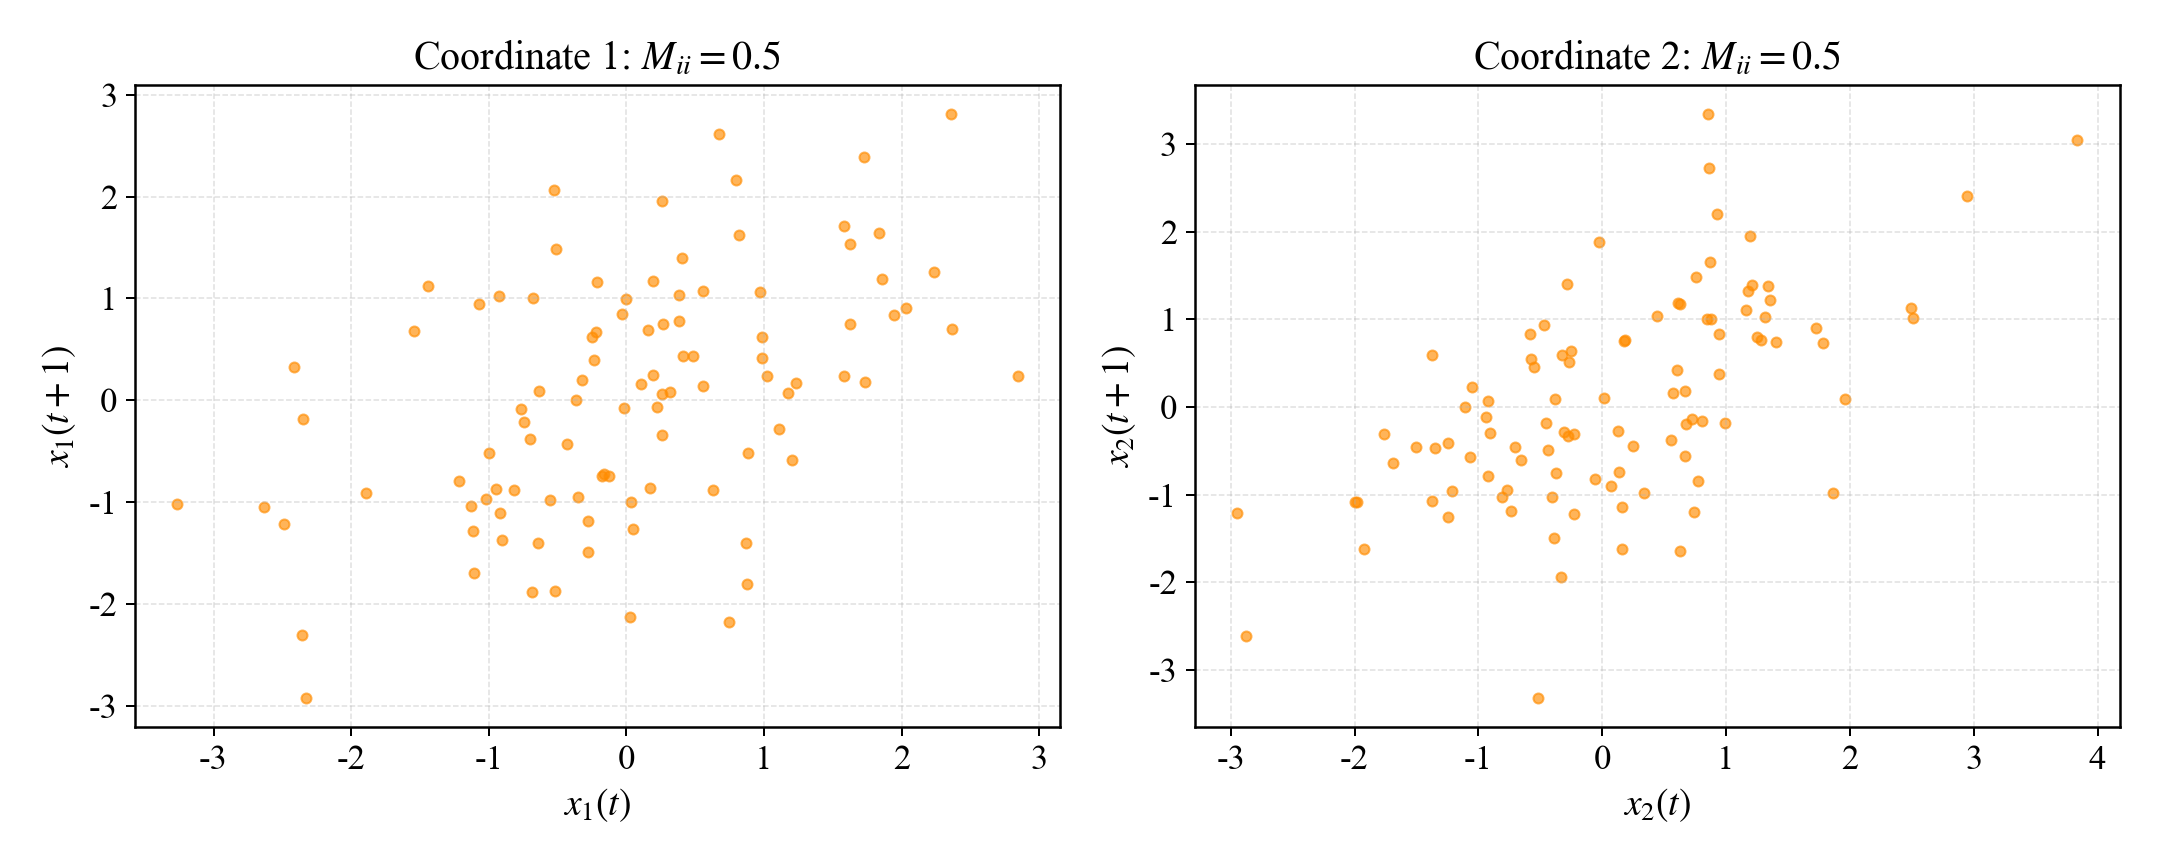

In [2]:
N_2D, SEED_2D, DT_2D = 100, 3, 1.0
M_2D = 0.5 * np.eye(2)
SIGMA_2D = (4.0 / 3.0) * np.eye(2)
rng = np.random.default_rng(SEED_2D)
X0_2D = gaussian_samples(rng, np.zeros(2), SIGMA_2D, size=N_2D)
X1_2D = X0_2D @ M_2D.T + rng.standard_normal((N_2D, 2))
panel_2d = [np.vstack((X0_2D[k], X1_2D[k])) for k in range(N_2D)]

estimate_2d = estimate_information_flow(
    panel_2d, [[0], [1]], dt=DT_2D, data_mode="panel", ridge_lambda=0.0
)
pair = (1, 0)  # source x_0 -> target x_1
value = float(estimate_2d["information_flow"][pair])
new_se = float(estimate_2d["information_flow_std"][pair])
old_se = float(estimate_2d["information_flow_std_origin"][pair])
result_2d = {
    "N": N_2D, "seed": SEED_2D, "dt": DT_2D,
    "M": M_2D, "Sigma": SIGMA_2D,
    "information_flow": value,
    "new_se": new_se, "new_p": 2 * norm.sf(abs(value) / new_se),
    "rudimentary_se": old_se, "rudimentary_p": 2 * norm.sf(abs(value) / old_se),
}
save_json(OUTPUT_DIR / "fixture_2d.json", {**result_2d, "metadata": PROVENANCE})
print(json.dumps({k: v for k, v in result_2d.items() if np.isscalar(v)}, indent=2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), dpi=180)
for index, axis in enumerate(axes):
    axis.scatter(X0_2D[:, index], X1_2D[:, index], s=16, alpha=0.65, color=C_NEW)
    axis.set_xlabel(fr"$x_{index + 1}(t)$")
    axis.set_ylabel(fr"$x_{index + 1}(t+1)$")
    axis.set_title(fr"Coordinate {index + 1}: $M_{{ii}}={M_2D[index,index]:.1f}$")
frame_axes(axes)
fig.tight_layout()
save_figure(fig, "two_dimensional_panel.png")
plt.show()


## 4.1.2 Panel-data benchmark: old versus new variance

Paper mode constructs 50 accepted six-dimensional systems, including 40 structural-null and 10 covariance-null designs. The matrices `A`, `B`, intercept `f`, stationary covariance `Sigma`, null/active masks, and accepted generation seeds remain in `panel_systems` and are serialized with the summary.


In [3]:
if RUN_MODE == "paper":
    PANEL_CFG = dict(
        n_systems=50, n_type1=5000, type1_repeats=100,
        sample_sizes=[500, 1000, 2000, 3000, 4000, 5000, 7500, 10000],
        variance_repeats=50, coverage_repeats=80, power_repeats=80,
    )
else:
    PANEL_CFG = dict(
        n_systems=2, n_type1=120, type1_repeats=3,
        sample_sizes=[80, 160],
        variance_repeats=3, coverage_repeats=3, power_repeats=3,
    )

D, DT = 6, 1.0
COMPONENT_SEGMENTS = [[i] for i in range(D)]
OFF = off_diagonal(D)
panel_systems = accepted_panel_systems(PANEL_CFG["n_systems"], dimension=D, dt=DT)
print("accepted systems:", len(panel_systems))
print("modes:", [system["mode"] for system in panel_systems])
print("first accepted A =\n", panel_systems[0]["A"])
print("first accepted B =\n", panel_systems[0]["B"])


accepted systems: 50
modes: ['structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'structural', 'covariance', 'covariance', 'covariance', 'covariance', 'covariance', 'covariance', 'covariance', 'covariance', 'covariance', 'covariance']
first accepted A =
 [[-0.97802483  0.          0.         -0.36396615  0.          0.        ]
 [ 0.22890405 -0.79810745  0.          0.          0.         -0.31920339]
 [-0.24607692  0.         -0.71495862  0.          0.          0.        ]
 [-0.20225029 -0.29525761 

In [4]:
# Type-I error at 90%, 95%, and 99% confidence.
confidence_levels = [0.90, 0.95, 0.99]

def _panel_type1_task(task):
    confidence, system_index = task
    system = panel_systems[system_index]
    critical = norm.ppf(1 - (1 - confidence) / 2)
    rejected_new, rejected_old = [], []
    for repetition in range(PANEL_CFG["type1_repeats"]):
        panel = generate_panel_data(
            PANEL_CFG["n_type1"], system["A"], system["B"], system["f"],
            system["Sigma"], DT, 100000 * system_index + 137 * repetition + 11,
        )
        estimate = estimate_information_flow(
            panel, COMPONENT_SEGMENTS, dt=DT, data_mode="panel", ridge_lambda=0.0
        )
        mask = system["null_pairs"]
        flow = np.abs(estimate["information_flow"][mask])
        rejected_new.append(100 * np.mean(flow / np.maximum(estimate["information_flow_std"][mask], 1e-12) > critical))
        rejected_old.append(100 * np.mean(flow / np.maximum(estimate["information_flow_std_origin"][mask], 1e-12) > critical))
    return confidence, system_index, rejected_new, rejected_old

_type1_tasks = [(confidence, system_index)
                for confidence in confidence_levels
                for system_index in range(len(panel_systems))]
_type1_results = sorted(parallel_map(_panel_type1_task, _type1_tasks),
                        key=lambda row: (row[0], row[1]))

type1_new, type1_old, type1_new_ci, type1_old_ci = [], [], [], []
for confidence in confidence_levels:
    rejected_new = [value for row in _type1_results if row[0] == confidence for value in row[2]]
    rejected_old = [value for row in _type1_results if row[0] == confidence for value in row[3]]
    new_mean, new_low, new_high = mean_ci95(rejected_new, upper=100)
    old_mean, old_low, old_high = mean_ci95(rejected_old, upper=100)
    type1_new.append(new_mean); type1_new_ci.append((new_high - new_low) / 2)
    type1_old.append(old_mean); type1_old_ci.append((old_high - old_low) / 2)
print("Type-I proposed (%):", np.round(type1_new, 3))
print("Type-I rudimentary (%):", np.round(type1_old, 3))


Type-I proposed (%): [7.427 3.453 0.613]
Type-I rudimentary (%): [18.443 14.061 10.417]


In [5]:
# Variance accuracy, confidence-interval coverage, and power.
sizes = PANEL_CFG["sample_sizes"]

def _panel_moment_task(task):
    system_index, N = task
    system = panel_systems[system_index]
    analytical = real_information_flow_linear_case(
        system["A"], system["B"], deg_freedom=N-D,
        segments=COMPONENT_SEGMENTS, discrete_lyapunov=True, dt=DT,
    )
    true_std = np.asarray(analytical["information_flow_std"])[OFF]
    valid = true_std > true_std.mean() * 0.01
    estimated_new, estimated_old = [], []
    for repetition in range(PANEL_CFG["variance_repeats"]):
        panel = generate_panel_data(N, system["A"], system["B"], system["f"], system["Sigma"], DT,
                                    300000 * system_index + 17 * repetition + N)
        estimate = estimate_information_flow(panel, COMPONENT_SEGMENTS, dt=DT, data_mode="panel", ridge_lambda=0.0)
        estimated_new.append(estimate["information_flow_std"][OFF])
        estimated_old.append(estimate["information_flow_std_origin"][OFF])
    variance_pair = []
    for estimates in (estimated_new, estimated_old):
        mean_estimate = np.mean(estimates, axis=0)
        variance_pair.append(100 * np.mean(np.abs(mean_estimate[valid] - true_std[valid]) / true_std[valid]))

    truth = system["true_if"][OFF]
    runs_new, runs_old = [], []
    for repetition in range(PANEL_CFG["coverage_repeats"]):
        panel = generate_panel_data(N, system["A"], system["B"], system["f"], system["Sigma"], DT,
                                    500000 * system_index + 31 * repetition + N)
        estimate = estimate_information_flow(panel, COMPONENT_SEGMENTS, dt=DT, data_mode="panel", ridge_lambda=0.0)
        point = estimate["information_flow"][OFF]
        for destination, key in ((runs_new, "information_flow_std"), (runs_old, "information_flow_std_origin")):
            standard_error = estimate[key][OFF]
            destination.append(100 * np.mean((truth >= point-Z95*standard_error) & (truth <= point+Z95*standard_error)))

    runs_power = []
    for repetition in range(PANEL_CFG["power_repeats"]):
        panel = generate_panel_data(N, system["A"], system["B"], system["f"], system["Sigma"], DT,
                                    700000 * system_index + 53 * repetition + 3 * N)
        estimate = estimate_information_flow(panel, COMPONENT_SEGMENTS, dt=DT, data_mode="panel", ridge_lambda=0.0)
        active = system["alt_pairs"]
        z_score = np.abs(estimate["information_flow"][active]) / np.maximum(estimate["information_flow_std"][active], 1e-12)
        runs_power.append(100 * np.mean(z_score > Z95))
    return (system_index, N, variance_pair[0], variance_pair[1],
            float(np.mean(runs_new)), float(np.mean(runs_old)), float(np.mean(runs_power)))

_moment_tasks = [(system_index, N)
                 for system_index in range(len(panel_systems)) for N in sizes]
_moment_results = parallel_map(_panel_moment_task, _moment_tasks)

variance_new = {N: [] for N in sizes}; variance_old = {N: [] for N in sizes}
coverage_new = {N: [] for N in sizes}; coverage_old = {N: [] for N in sizes}
power_new = {N: [] for N in sizes}
for system_index, N, var_new, var_old, cov_new, cov_old, power in _moment_results:
    variance_new[N].append(var_new); variance_old[N].append(var_old)
    coverage_new[N].append(cov_new); coverage_old[N].append(cov_old)
    power_new[N].append(power)

def interval_arrays(values):
    return tuple(np.asarray(part) for part in zip(*(mean_ci95(values[N], upper=100) for N in sizes)))

var_new_mean, var_new_low, var_new_high = interval_arrays(variance_new)
var_old_mean, var_old_low, var_old_high = interval_arrays(variance_old)
cov_new_mean, cov_new_low, cov_new_high = interval_arrays(coverage_new)
cov_old_mean, cov_old_low, cov_old_high = interval_arrays(coverage_old)
power_mean, power_low, power_high = interval_arrays(power_new)
type2_mean, type2_low, type2_high = 100-power_mean, 100-power_high, 100-power_low


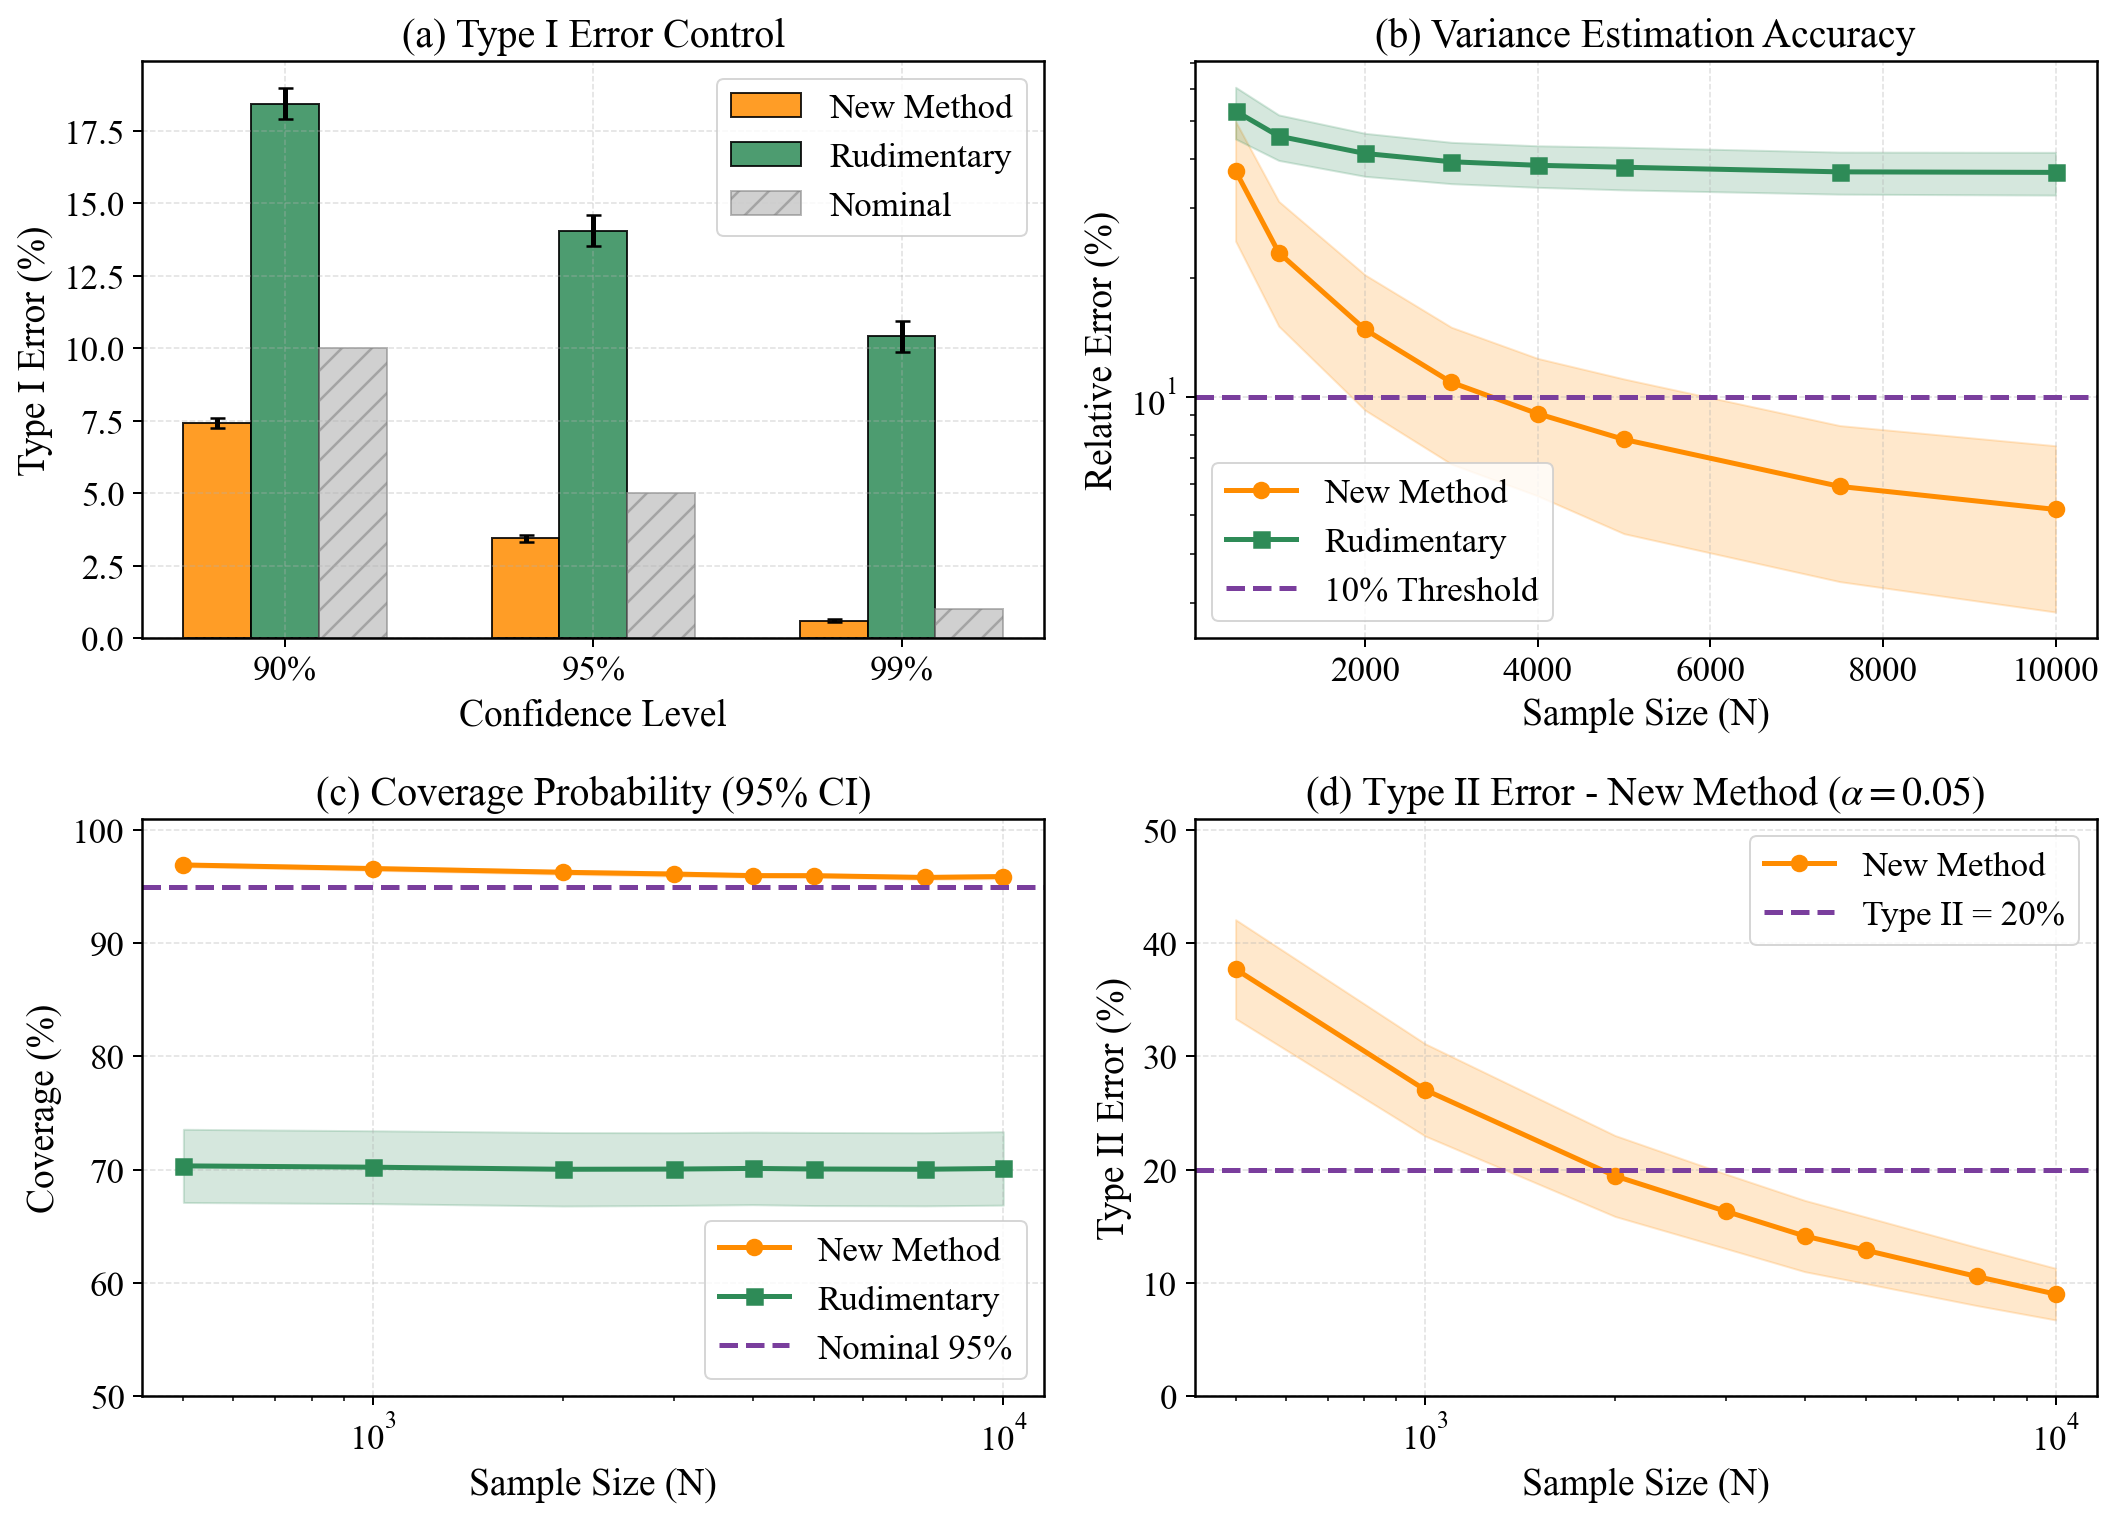

In [6]:
panel_summary = {
    "config": PANEL_CFG, "confidence_levels": confidence_levels,
    "type1_new": type1_new, "type1_rudimentary": type1_old,
    "type1_new_ci": type1_new_ci, "type1_rudimentary_ci": type1_old_ci,
    "sample_sizes": sizes,
    "variance_new": [var_new_mean, var_new_low, var_new_high],
    "variance_rudimentary": [var_old_mean, var_old_low, var_old_high],
    "coverage_new": [cov_new_mean, cov_new_low, cov_new_high],
    "coverage_rudimentary": [cov_old_mean, cov_old_low, cov_old_high],
    "type2_new": [type2_mean, type2_low, type2_high],
    "systems": panel_systems, "metadata": PROVENANCE,
}
save_json(OUTPUT_DIR / "statistical_validation_summary.json", panel_summary)

fig, axes = plt.subplots(2, 2, figsize=(12, 8.7), dpi=180)
frame_axes(axes)
x = np.arange(len(confidence_levels)); width = 0.22
axes[0,0].bar(x-width, type1_new, width, yerr=type1_new_ci, capsize=3, color=C_NEW, alpha=.85, edgecolor="black", label="New Method")
axes[0,0].bar(x, type1_old, width, yerr=type1_old_ci, capsize=3, color=C_RUD, alpha=.85, edgecolor="black", label="Rudimentary")
axes[0,0].bar(x+width, 100*(1-np.asarray(confidence_levels)), width, color="#AAAAAA", alpha=.55, hatch="//", edgecolor="gray", label="Nominal")
axes[0,0].set(title="(a) Type I Error Control", xlabel="Confidence Level", ylabel="Type I Error (%)")
axes[0,0].set_xticks(x, [f"{int(level*100)}%" for level in confidence_levels]); axes[0,0].legend()

axes[0,1].semilogy(sizes, var_new_mean, "o-", color=C_NEW, label="New Method")
axes[0,1].fill_between(sizes, var_new_low, var_new_high, color=C_NEW, alpha=.2)
axes[0,1].semilogy(sizes, var_old_mean, "s-", color=C_RUD, label="Rudimentary")
axes[0,1].fill_between(sizes, var_old_low, var_old_high, color=C_RUD, alpha=.2)
axes[0,1].axhline(10, color=C_THR, ls="--", label="10% Threshold")
axes[0,1].set(title="(b) Variance Estimation Accuracy", xlabel="Sample Size (N)", ylabel="Relative Error (%)"); axes[0,1].legend()

axes[1,0].semilogx(sizes, cov_new_mean, "o-", color=C_NEW, label="New Method")
axes[1,0].fill_between(sizes, cov_new_low, cov_new_high, color=C_NEW, alpha=.2)
axes[1,0].semilogx(sizes, cov_old_mean, "s-", color=C_RUD, label="Rudimentary")
axes[1,0].fill_between(sizes, cov_old_low, cov_old_high, color=C_RUD, alpha=.2)
axes[1,0].axhline(95, color=C_THR, ls="--", label="Nominal 95%")
axes[1,0].set(title="(c) Coverage Probability (95% CI)", xlabel="Sample Size (N)", ylabel="Coverage (%)", ylim=(50,101)); axes[1,0].legend(loc="lower right")

axes[1,1].semilogx(sizes, type2_mean, "o-", color=C_NEW, label="New Method")
axes[1,1].fill_between(sizes, type2_low, type2_high, color=C_NEW, alpha=.2)
axes[1,1].axhline(20, color=C_THR, ls="--", label="Type II = 20%")
axes[1,1].set(title=r"(d) Type II Error - New Method ($\alpha=0.05$)", xlabel="Sample Size (N)", ylabel="Type II Error (%)", ylim=(0,51)); axes[1,1].legend()
fig.tight_layout()
save_figure(fig, "statistical_validation_summary.png")
plt.show()


## 4.2.1 Sampling density and HAC correction

Paper mode uses 100 six-dimensional systems, `N_obs=3000`, 10 trajectories per system, and all 14 observation intervals from 0.001 to 0.12. For every generated trajectory, the no-HAC and HAC calls share the point estimator and differ only in `data_mode`.


In [7]:
if RUN_MODE == "paper":
    EXP2_CFG = dict(n_systems=100, repetitions=10, n_obs=3000,
                    dts=[.001,.005,.01,.02,.03,.04,.05,.06,.07,.08,.09,.10,.11,.12])
else:
    EXP2_CFG = dict(n_systems=2, repetitions=2, n_obs=300, dts=[.01,.04,.12])
EXP2_SEGMENTS = [[0,1], [2,3], [4,5]]
EXP2_BUILDER = dict(cross_scale=.50, diagonal_damping=(.5,.9), stability_margin=.05,
                    min_active_flow_magnitude=.15)
exp2_systems = [
    build_dynamical_system(6, EXP2_SEGMENTS, seed=200+system_id, **EXP2_BUILDER)
    for system_id in range(EXP2_CFG["n_systems"])
]
print("exp2 config:", EXP2_CFG)
print("first system true subspace IF =\n", exp2_systems[0].subspace_information_flow)


exp2 config: {'n_systems': 100, 'repetitions': 10, 'n_obs': 3000, 'dts': [0.001, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12]}
first system true subspace IF =
 [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.38777878e-17  0.00000000e+00  2.85727494e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]


In [8]:
def _exp2_task(task):
    system_id, dt = task
    system = exp2_systems[system_id]
    rows = []
    for repetition in range(EXP2_CFG["repetitions"]):
        seed = 1_000_000 + 1000*system_id + int(dt*10_000) + repetition
        series = simulate(system.A, system.Sigma, sim_dt=dt, subsample_factor=1,
                          n_obs=EXP2_CFG["n_obs"], seed=seed)
        diagnostics = autocorrelation_diagnostics(series, EXP2_SEGMENTS)
        for method, data_mode in (("panel", "panel"), ("hac", "time_series")):
            estimate = estimate_information_flow(
                series, EXP2_SEGMENTS, dt=dt, data_mode=data_mode, ridge_lambda="auto"
            )
            rows.append({
                "system_id": system_id, "dt": dt, "n_obs": EXP2_CFG["n_obs"],
                "rep": repetition, "method": method, "seed": seed,
                "hac_max_lag_used": estimate.get("hac_max_lag_used"),
                **diagnostics,
                **trajectory_metrics(estimate, system.subspace_information_flow),
            })
    return rows

_exp2_tasks = [(system_id, dt)
               for system_id in range(EXP2_CFG["n_systems"]) for dt in EXP2_CFG["dts"]]
exp2_rows = [row for rows in parallel_map(_exp2_task, _exp2_tasks) for row in rows]
exp2_summary = summarize_time_series_rows(exp2_rows, ("dt", "method"))
exp2_result = {
    "config": {**EXP2_CFG, "segments": EXP2_SEGMENTS, "builder": EXP2_BUILDER},
    "systems": exp2_systems, "rows": exp2_rows, "summary": exp2_summary,
    "metadata": PROVENANCE,
}
save_json(OUTPUT_DIR / "exp2_summary.json", exp2_result)
print("trajectory/method rows:", len(exp2_rows))


trajectory/method rows: 28000


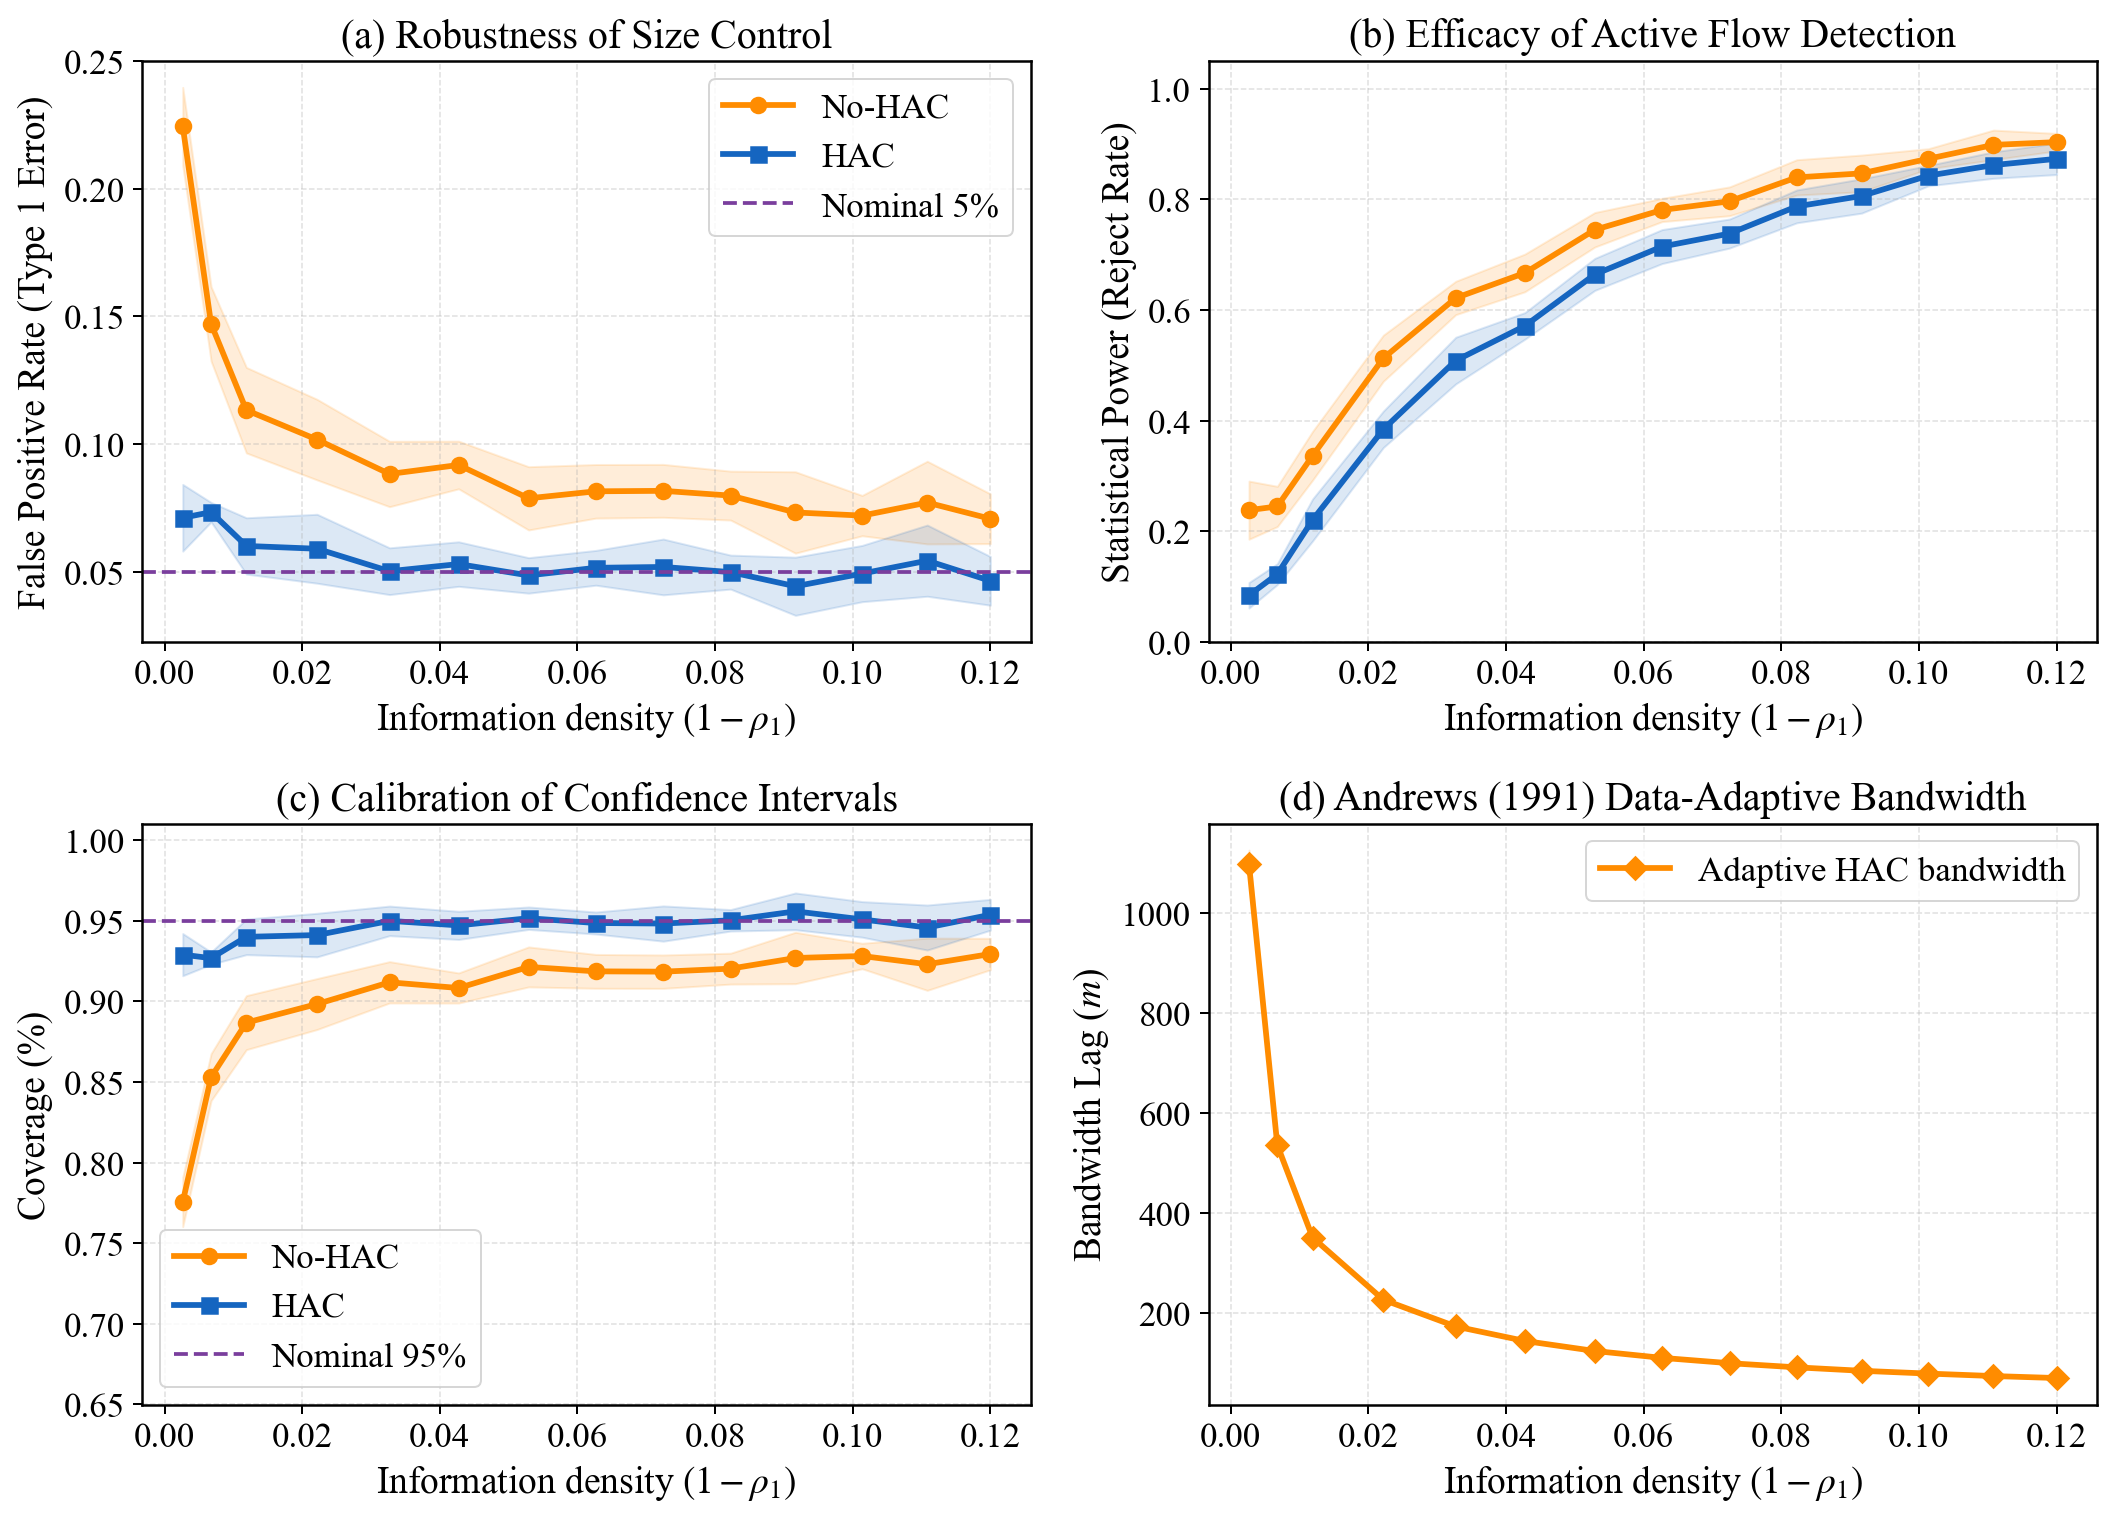

In [9]:
def scalar(row, key):
    value = row[key]
    return float(value["mean"] if isinstance(value, dict) else value)

def repeat_std(row, key):
    value = row.get(f"{key}_across_repeats", {"std": 0.0})
    return float(value.get("std", 0.0) if isinstance(value, dict) else value)

panel_rows = sorted((row for row in exp2_summary if row["method"] == "panel"), key=lambda row: row["dt"])
hac_rows = sorted((row for row in exp2_summary if row["method"] == "hac"), key=lambda row: row["dt"])
information_density = 1 - np.asarray([scalar(row, "mean_seg_lag1_autocorr") for row in panel_rows])
order = np.argsort(information_density); x = information_density[order]

fig, axes = plt.subplots(2, 2, figsize=(12, 8.7), dpi=180)
frame_axes(axes)
specs = [
    ("type1_error", "False Positive Rate (Type 1 Error)", "(a) Robustness of Size Control", .05),
    ("power", "Statistical Power (Reject Rate)", "(b) Efficacy of Active Flow Detection", None),
    ("null_coverage", "Coverage (%)", "(c) Calibration of Confidence Intervals", .95),
]
for axis, (key, ylabel, title, reference) in zip(axes.flat[:3], specs):
    for rows, color, marker, label in ((panel_rows,C_NEW,"o","No-HAC"),(hac_rows,C_HAC,"s","HAC")):
        center = np.asarray([scalar(row,key) for row in rows])[order]
        spread = np.asarray([repeat_std(row,key) for row in rows])[order]
        axis.fill_between(x, np.clip(center-spread,0,1), np.clip(center+spread,0,1), color=color, alpha=.15)
        axis.plot(x, center, marker=marker, lw=2.3, color=color, label=label)
    if reference is not None:
        axis.axhline(reference, color=C_THR, ls="--", lw=1.5, label=f"Nominal {100*reference:.0f}%")
    axis.set(xlabel=r"Information density $(1-\rho_1)$", ylabel=ylabel, title=title)
    if key != "power": axis.legend()
    if key == "power": axis.set_ylim(0,1.05)
    if key == "null_coverage": axis.set_ylim(.65,1.01)

bandwidth = np.asarray([scalar(row,"hac_max_lag_used") for row in hac_rows])[order]
bandwidth_std = np.asarray([repeat_std(row,"hac_max_lag_used") for row in hac_rows])[order]
axes[1,1].fill_between(x, np.clip(bandwidth-bandwidth_std,0,None), bandwidth+bandwidth_std, color=C_NEW, alpha=.18)
axes[1,1].plot(x, bandwidth, marker="D", lw=2.3, color=C_NEW, label="Adaptive HAC bandwidth")
axes[1,1].set(xlabel=r"Information density $(1-\rho_1)$", ylabel=r"Bandwidth Lag ($m$)", title="(d) Andrews (1991) Data-Adaptive Bandwidth")
axes[1,1].legend()
fig.tight_layout()
save_figure(fig, "hac_fancy_plot.png")
plt.show()


## 4.2.2 Dimension and subspace-resolution sweeps

A subspace is an explicit coordinate-index block. The dimension sweep uses three balanced blocks for each total dimension. The resolution sweep fixes total dimension 12 and uses 2, 3, 4, or 5 balanced blocks. The equations and generator are otherwise identical to Section 4.2.1.


In [10]:
if RUN_MODE == "paper":
    EXP3_CFG = dict(n_systems=100, repetitions=10, n_obs=3000, dts=[.02,.04,.06],
                    dimensions=[6,8,10,12,14,16,18], subspace_counts=[2,3,4,5])
else:
    EXP3_CFG = dict(n_systems=1, repetitions=1, n_obs=250, dts=[.02,.06],
                    dimensions=[6,10], subspace_counts=[2,4])

def dimension_builder_kwargs(dimension):
    return dict(cross_scale=.38+.004*((dimension-6)//2), diagonal_damping=(.5,.9),
                stability_margin=.05, structural_zero_probability=.28,
                cancellation_zero_probability=.20,
                min_active_flow_magnitude=.05+.002*((dimension-6)//2), max_tries=40_000)

def subspace_builder_kwargs(count):
    fragility = max(0, count-4)
    return dict(cross_scale=.30+.004*np.log2(count), diagonal_damping=(.5,.9),
                stability_margin=.05,
                structural_zero_probability=max(.08,.18-.02*fragility),
                cancellation_zero_probability=max(.04,.10-.015*fragility),
                min_active_flow_magnitude=max(.015,.035-.004*fragility), max_tries=60_000)

scenarios = []
for dimension in EXP3_CFG["dimensions"]:
    scenarios.append(dict(scenario=f"dim_{dimension}", sweep="dimension", dimension=dimension,
                          n_subspaces=3, segments=balanced_segments(dimension,3),
                          builder_kwargs=dimension_builder_kwargs(dimension)))
for count in EXP3_CFG["subspace_counts"]:
    scenarios.append(dict(scenario=f"subspaces_{count}", sweep="subspace_count", dimension=12,
                          n_subspaces=count, segments=balanced_segments(12,count),
                          builder_kwargs=subspace_builder_kwargs(count)))
scenario_index = {scenario["scenario"]: index for index, scenario in enumerate(scenarios)}
print(json.dumps([{k:v for k,v in scenario.items() if k != "builder_kwargs"} for scenario in scenarios], indent=2))


[
  {
    "scenario": "dim_6",
    "sweep": "dimension",
    "dimension": 6,
    "n_subspaces": 3,
    "segments": [
      [
        0,
        1
      ],
      [
        2,
        3
      ],
      [
        4,
        5
      ]
    ]
  },
  {
    "scenario": "dim_8",
    "sweep": "dimension",
    "dimension": 8,
    "n_subspaces": 3,
    "segments": [
      [
        0,
        1,
        2
      ],
      [
        3,
        4,
        5
      ],
      [
        6,
        7
      ]
    ]
  },
  {
    "scenario": "dim_10",
    "sweep": "dimension",
    "dimension": 10,
    "n_subspaces": 3,
    "segments": [
      [
        0,
        1,
        2,
        3
      ],
      [
        4,
        5,
        6
      ],
      [
        7,
        8,
        9
      ]
    ]
  },
  {
    "scenario": "dim_12",
    "sweep": "dimension",
    "dimension": 12,
    "n_subspaces": 3,
    "segments": [
      [
        0,
        1,
        2,
        3
      ],
      [
        4,
        5,
      

In [11]:
_scenario_by_name = {scenario["scenario"]: scenario for scenario in scenarios}

def _exp3_build_task(task):
    scenario_name, system_id = task
    scenario = _scenario_by_name[scenario_name]
    scenario_id = scenario_index[scenario_name]
    for retry in range(5):
        try:
            system = build_dynamical_system(
                scenario["dimension"], scenario["segments"],
                seed=5000 + 1000*scenario_id + 10*system_id + retry,
                **scenario["builder_kwargs"],
            )
            return {"scenario":scenario_name, "system_id":system_id, "system":system}
        except RuntimeError:
            pass
    raise RuntimeError(f"could not construct {scenario_name} system {system_id}")

_build_tasks = [(scenario["scenario"], system_id)
                for scenario in scenarios
                for system_id in range(EXP3_CFG["n_systems"])]
exp3_systems = parallel_map(_exp3_build_task, _build_tasks)

def _exp3_task(task):
    slot, dt = task
    entry = exp3_systems[slot]
    scenario = _scenario_by_name[entry["scenario"]]
    scenario_id = scenario_index[entry["scenario"]]
    system_id = entry["system_id"]
    system = entry["system"]
    rows = []
    for repetition in range(EXP3_CFG["repetitions"]):
        seed = 2_000_000 + 100_000*scenario_id + 1000*system_id + int(dt*10_000) + repetition
        series = simulate(system.A, system.Sigma, sim_dt=dt, subsample_factor=1,
                          n_obs=EXP3_CFG["n_obs"], seed=seed)
        diagnostics = autocorrelation_diagnostics(series, scenario["segments"])
        for method, data_mode in (("panel","panel"),("hac","time_series")):
            estimate = estimate_information_flow(series, scenario["segments"], dt=dt,
                                                 data_mode=data_mode, ridge_lambda="auto")
            rows.append({
                "scenario":scenario["scenario"], "sweep":scenario["sweep"],
                "dimension":scenario["dimension"], "n_subspaces":scenario["n_subspaces"],
                "system_id":system_id, "dt":dt, "rep":repetition, "method":method,
                "n_obs":EXP3_CFG["n_obs"], "seed":seed,
                "hac_max_lag_used":estimate.get("hac_max_lag_used"),
                **diagnostics, **trajectory_metrics(estimate, system.subspace_information_flow),
            })
    return rows

_exp3_tasks = [(slot, dt) for slot in range(len(exp3_systems)) for dt in EXP3_CFG["dts"]]
exp3_rows = [row for rows in parallel_map(_exp3_task, _exp3_tasks) for row in rows]
exp3_summary = summarize_time_series_rows(
    exp3_rows, ("scenario","sweep","dimension","n_subspaces","dt","method")
)
exp3_result = {"config":EXP3_CFG, "scenarios":scenarios, "systems":exp3_systems,
               "rows":exp3_rows, "summary":exp3_summary, "metadata":PROVENANCE}
save_json(OUTPUT_DIR / "exp3_summary.json", exp3_result)
print("systems:", len(exp3_systems), "trajectory/method rows:", len(exp3_rows))


systems: 1100 trajectory/method rows: 66000


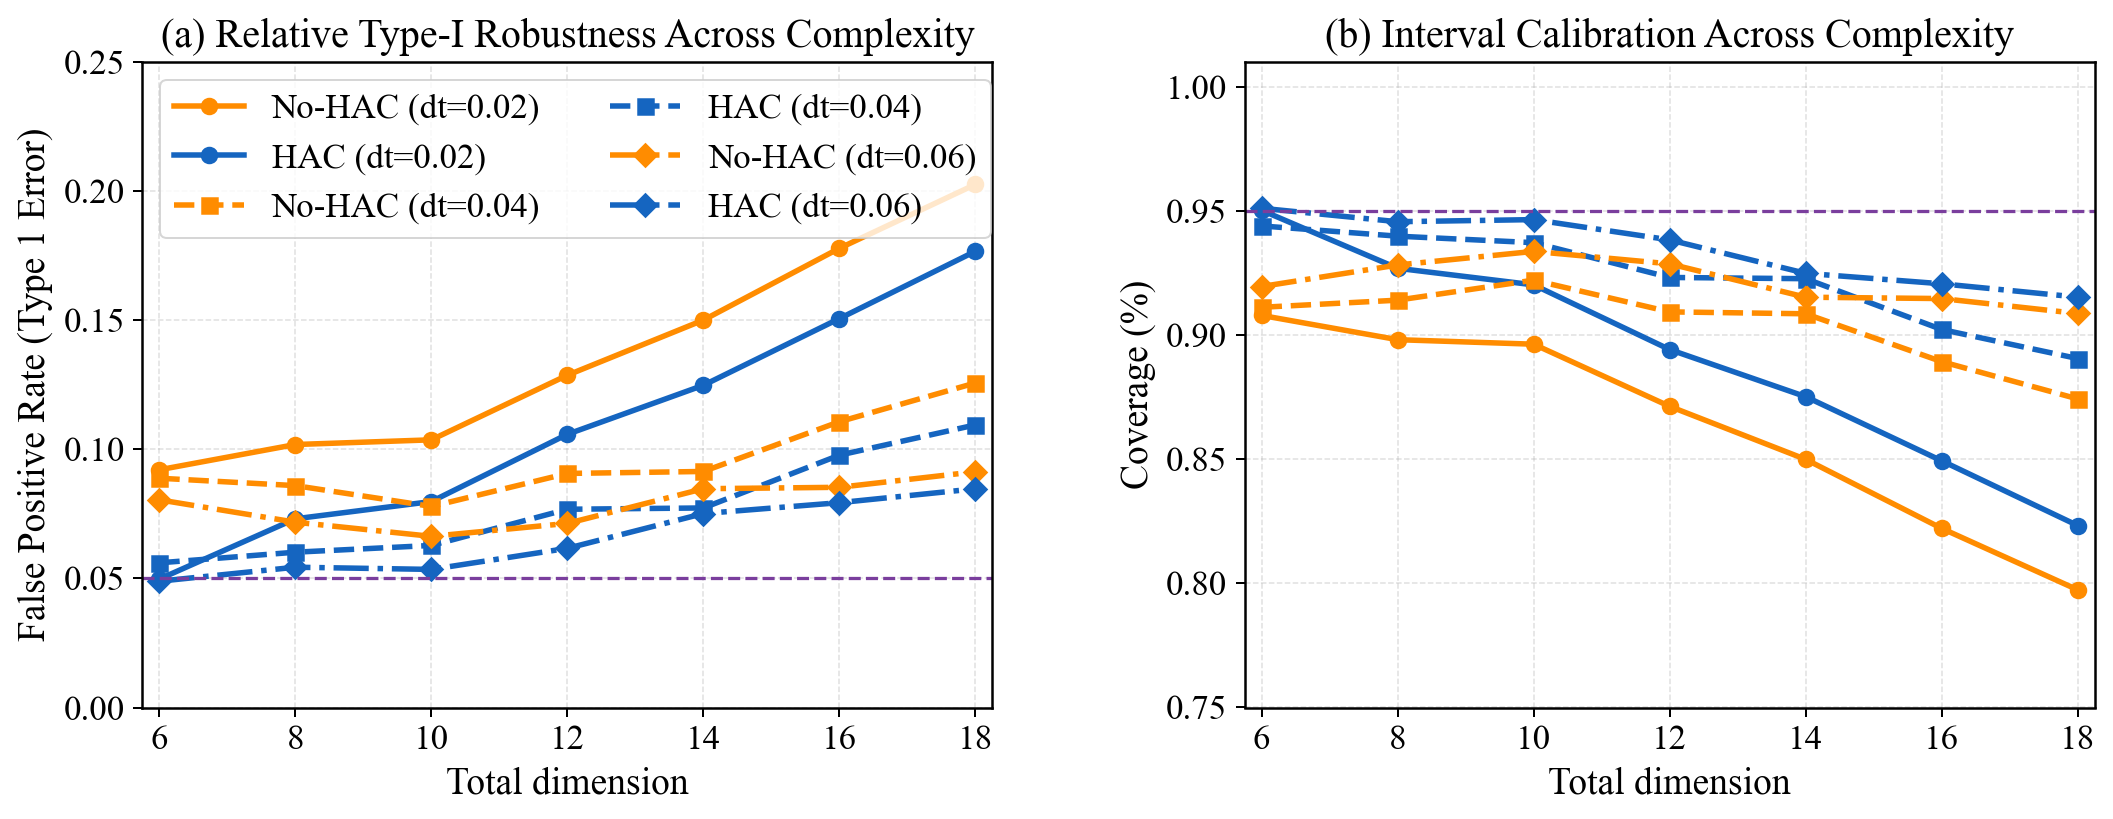

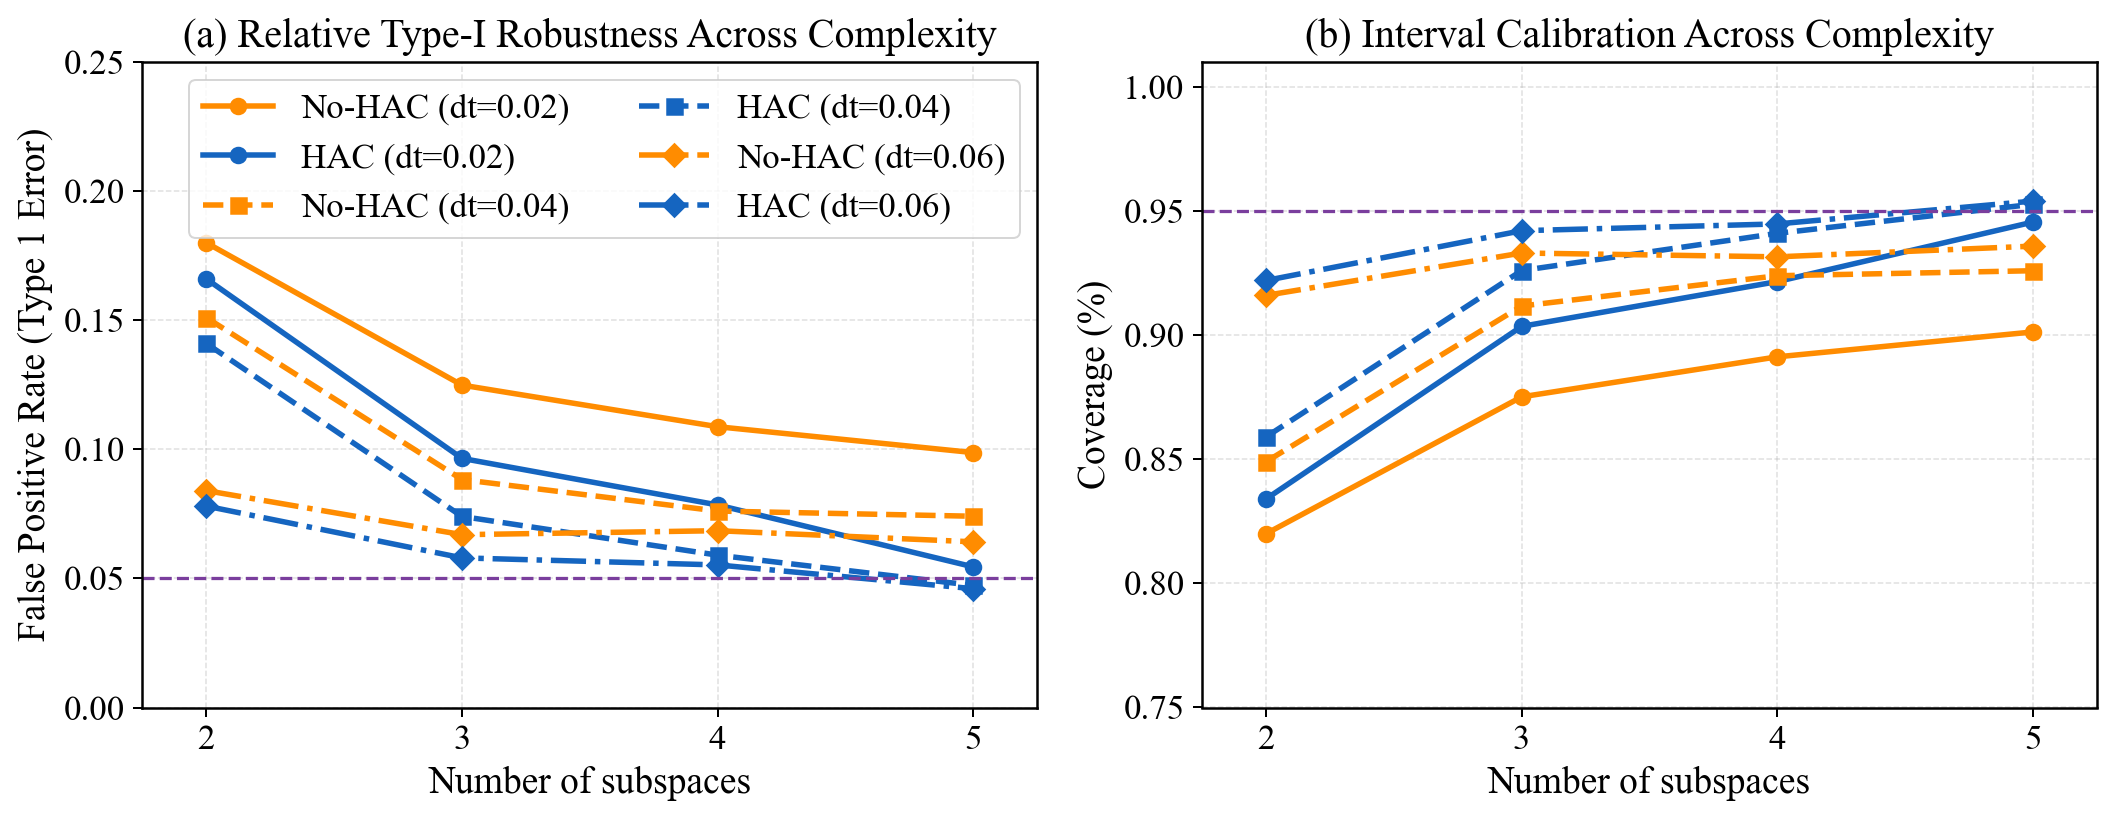

In [12]:
DT_STYLES = {.02:("o","solid"), .04:("s","dashed"), .06:("D","dashdot")}

def plot_complexity_sweep(sweep, filename):
    rows = [row for row in exp3_summary if row["sweep"] == sweep]
    x_key = "dimension" if sweep == "dimension" else "n_subspaces"
    x_label = "Total dimension" if sweep == "dimension" else "Number of subspaces"
    ticks = sorted({int(row[x_key]) for row in rows})
    fig, axes = plt.subplots(1,2,figsize=(12,4.8),dpi=180)
    frame_axes(axes); handles=[]; labels=[]
    for axis, (key,ylabel,title,ylim,reference) in zip(axes, [
        ("type1_error","False Positive Rate (Type 1 Error)","(a) Relative Type-I Robustness Across Complexity",(0,.25),.05),
        ("null_coverage","Coverage (%)","(b) Interval Calibration Across Complexity",(.75,1.01),.95),
    ]):
        for dt in EXP3_CFG["dts"]:
            marker, linestyle = DT_STYLES.get(dt,("o","solid"))
            for method,color,name in (("panel",C_NEW,"No-HAC"),("hac",C_HAC,"HAC")):
                selected = sorted((row for row in rows if row["method"]==method and np.isclose(row["dt"],dt)),
                                  key=lambda row: row[x_key])
                line, = axis.plot([row[x_key] for row in selected], [scalar(row,key) for row in selected],
                                  marker=marker, ls=linestyle, color=color, lw=2.2,
                                  label=f"{name} (dt={dt:.2f})")
                if key == "type1_error": handles.append(line); labels.append(line.get_label())
        axis.axhline(reference,color=C_THR,ls="--",lw=1.3)
        axis.set(xlabel=x_label,ylabel=ylabel,title=title,ylim=ylim)
        axis.set_xticks(ticks); axis.set_xlim(min(ticks)-.25,max(ticks)+.25)
    axes[0].legend(handles,labels,loc="upper right" if sweep=="subspace_count" else "upper left",ncol=2)
    fig.tight_layout(); save_figure(fig,filename); plt.show()
    return fig

dimension_figure = plot_complexity_sweep("dimension", "exp3_dimension_sweep.png")
subspace_figure = plot_complexity_sweep("subspace_count", "exp3_subspace_sweep.png")


# Supplementary experiments

## Component-wise analytical variance and bootstrap

The program intentionally executes `N=500` before the two plotted paper sizes `N=1000,5000`, because the archived code used one global NumPy bootstrap stream in that order. This preserves the historical RNG state for the plotted figures.


/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


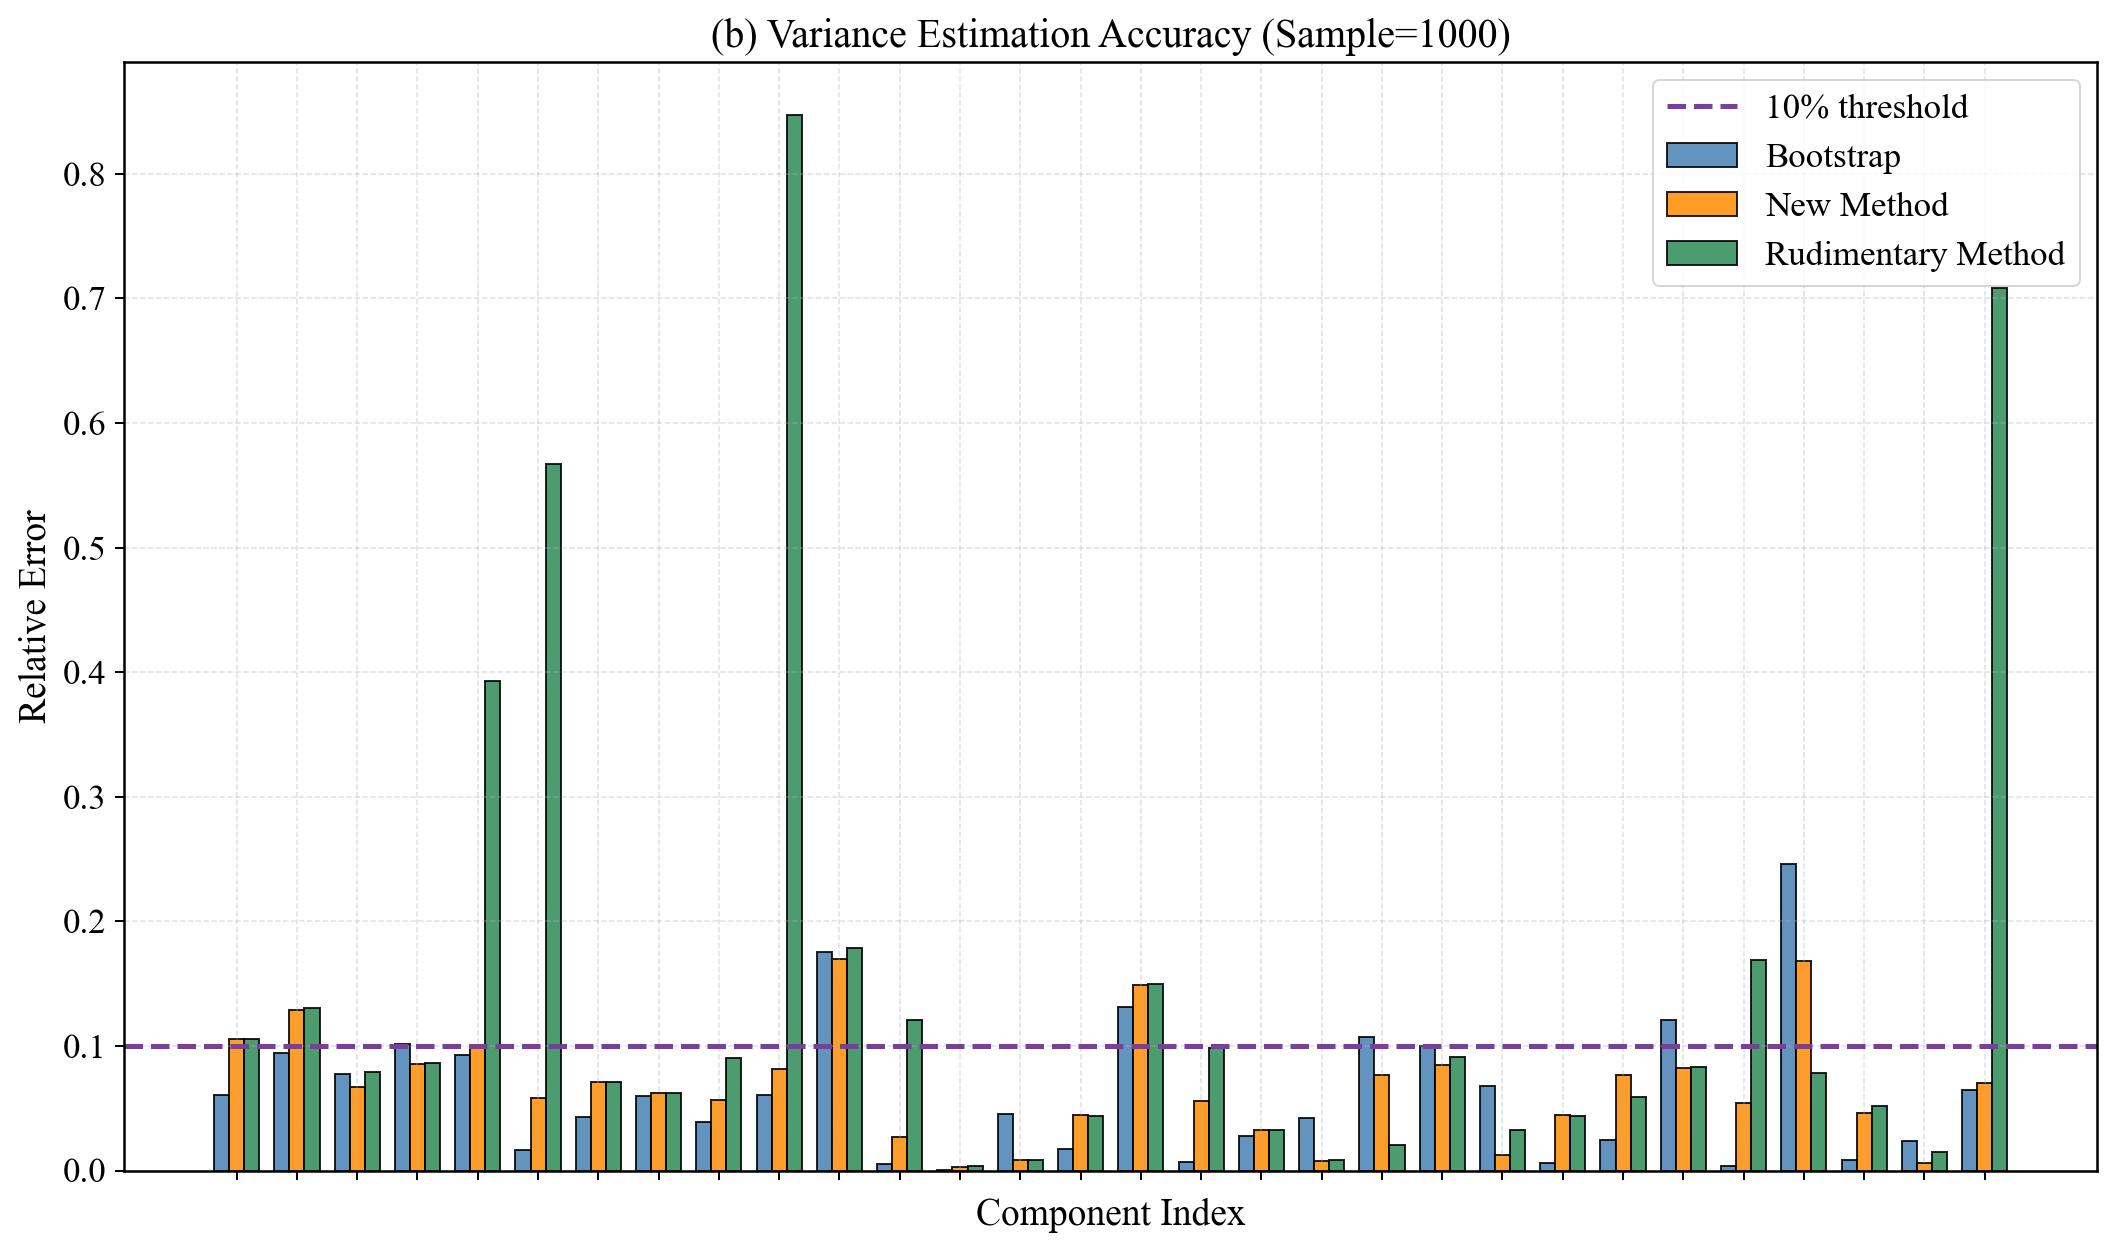

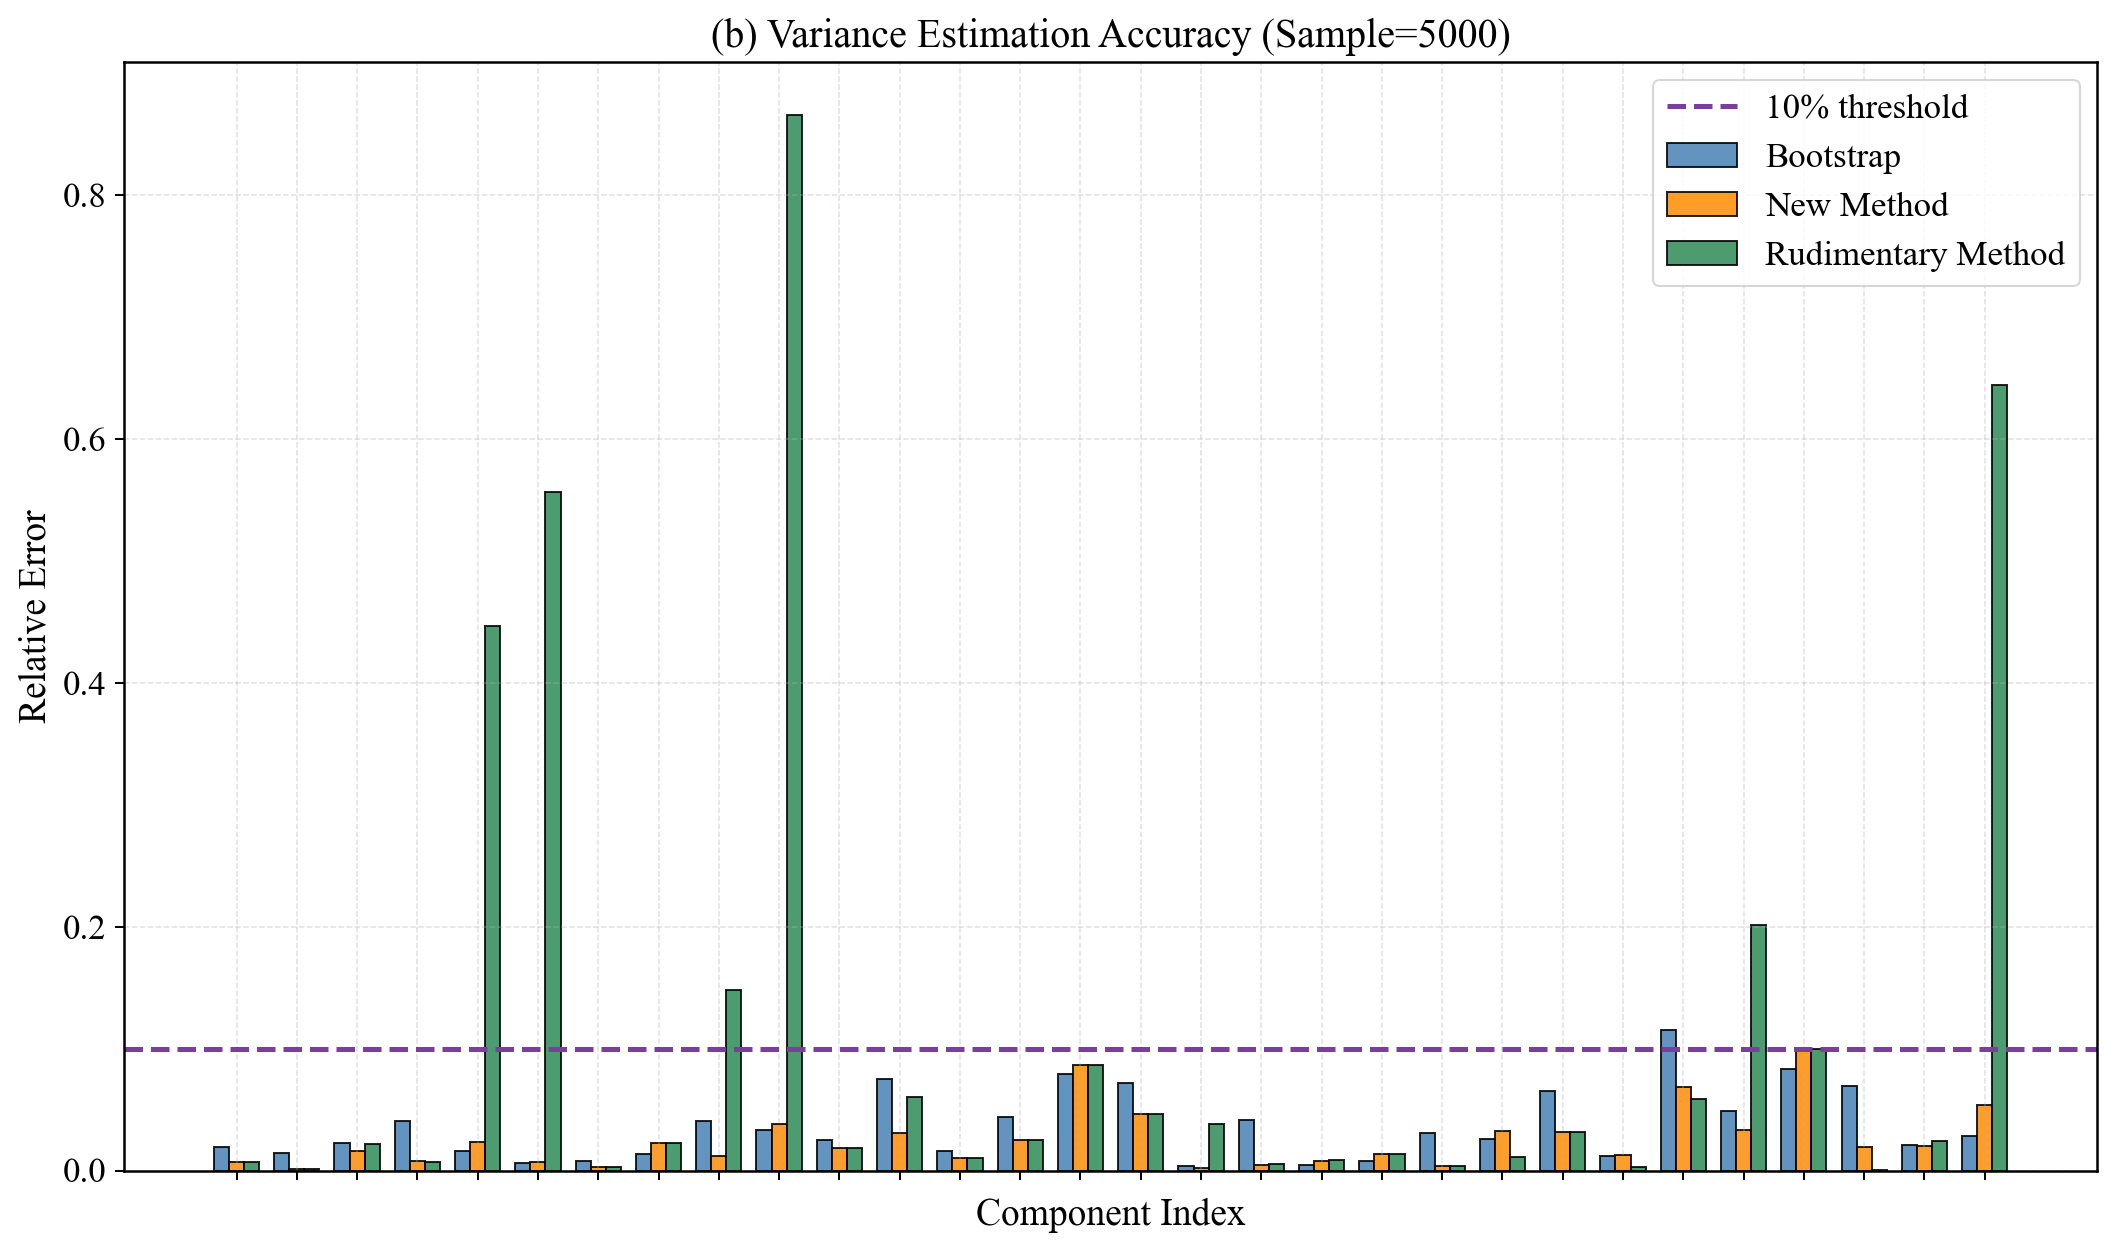

In [2]:
FIXED_A = np.array([
    [-.1,0,0,-.1,0,-.3], [.6,-.2,0,0,-.4,.5], [0,.6,-.8,.1,0,0],
    [0,.1,0,-.8,0,0], [0,.3,-.1,.6,-.7,0], [-.2,0,-.1,0,.6,-.5],
])
component_sizes = [500,1000,5000] if RUN_MODE == "paper" else [120,240]
component_bootstrap_count = 1000 if RUN_MODE == "paper" else 40
np.random.seed(27)
component_B = np.random.randn(6,6)
component_Sigma = solve_discrete_lyapunov(np.eye(6)+FIXED_A, component_B@component_B.T)
component_results = []
for N in component_sizes:
    panel = generate_panel_data(N,FIXED_A,component_B,np.zeros(6),component_Sigma,1.0,42)
    estimate = estimate_information_flow(panel,[[i] for i in range(6)],dt=1.0,data_mode="panel",ridge_lambda=0.0)
    bootstrap = bootstrap_estimate(panel,dt=1.0,segments=[[i] for i in range(6)],
                                   bootstrap_num=component_bootstrap_count,rng=np.random)
    truth = real_information_flow_linear_case(FIXED_A,component_B,deg_freedom=N-6,
                                               segments=[[i] for i in range(6)],discrete_lyapunov=True,dt=1.0)
    mask = off_diagonal(6); true_std = truth["information_flow_std"][mask]
    component_results.append({
        "N":N, "true_std":true_std,
        "bootstrap_error":np.abs(bootstrap["bootstrap_information_flow_std"][mask]-true_std)/true_std,
        "new_error":np.abs(estimate["information_flow_std"][mask]-true_std)/true_std,
        "rudimentary_error":np.abs(estimate["information_flow_std_origin"][mask]-true_std)/true_std,
    })
save_json(OUTPUT_DIR/"component_bootstrap.json", {"results":component_results,"metadata":PROVENANCE})

component_plot_rows = (
    [row for row in component_results if row["N"] in (1000,5000)]
    if RUN_MODE == "paper" else component_results
)
for row in component_plot_rows:
    x=np.arange(len(row["new_error"])); width=.25
    fig,axis=plt.subplots(figsize=(12,7.2),dpi=180)
    axis.bar(x-width,row["bootstrap_error"],width,label="Bootstrap",color=C_BOOT,alpha=.85,edgecolor="black")
    axis.bar(x,row["new_error"],width,label="New Method",color=C_NEW,alpha=.85,edgecolor="black")
    axis.bar(x+width,row["rudimentary_error"],width,label="Rudimentary Method",color=C_RUD,alpha=.85,edgecolor="black")
    axis.axhline(.1,color=C_THR,ls="--",label="10% threshold")
    axis.set(title=f"(b) Variance Estimation Accuracy (Sample={row['N']})",xlabel="Component Index",ylabel="Relative Error")
    axis.set_xticks(x,[]); axis.legend(); frame_axes([axis]); fig.tight_layout()
    save_figure(fig,f"2_error_comparison_s_{row['N']}_b_{component_bootstrap_count}.png"); plt.show()


## Subspace-wise analytical variance and bootstrap

The six variables are partitioned exactly as `alpha_1={x1,x2}`, `alpha_2={x3,x4}`, and `alpha_3={x5,x6}`. Each dataset again consists of independent two-time-point panels.


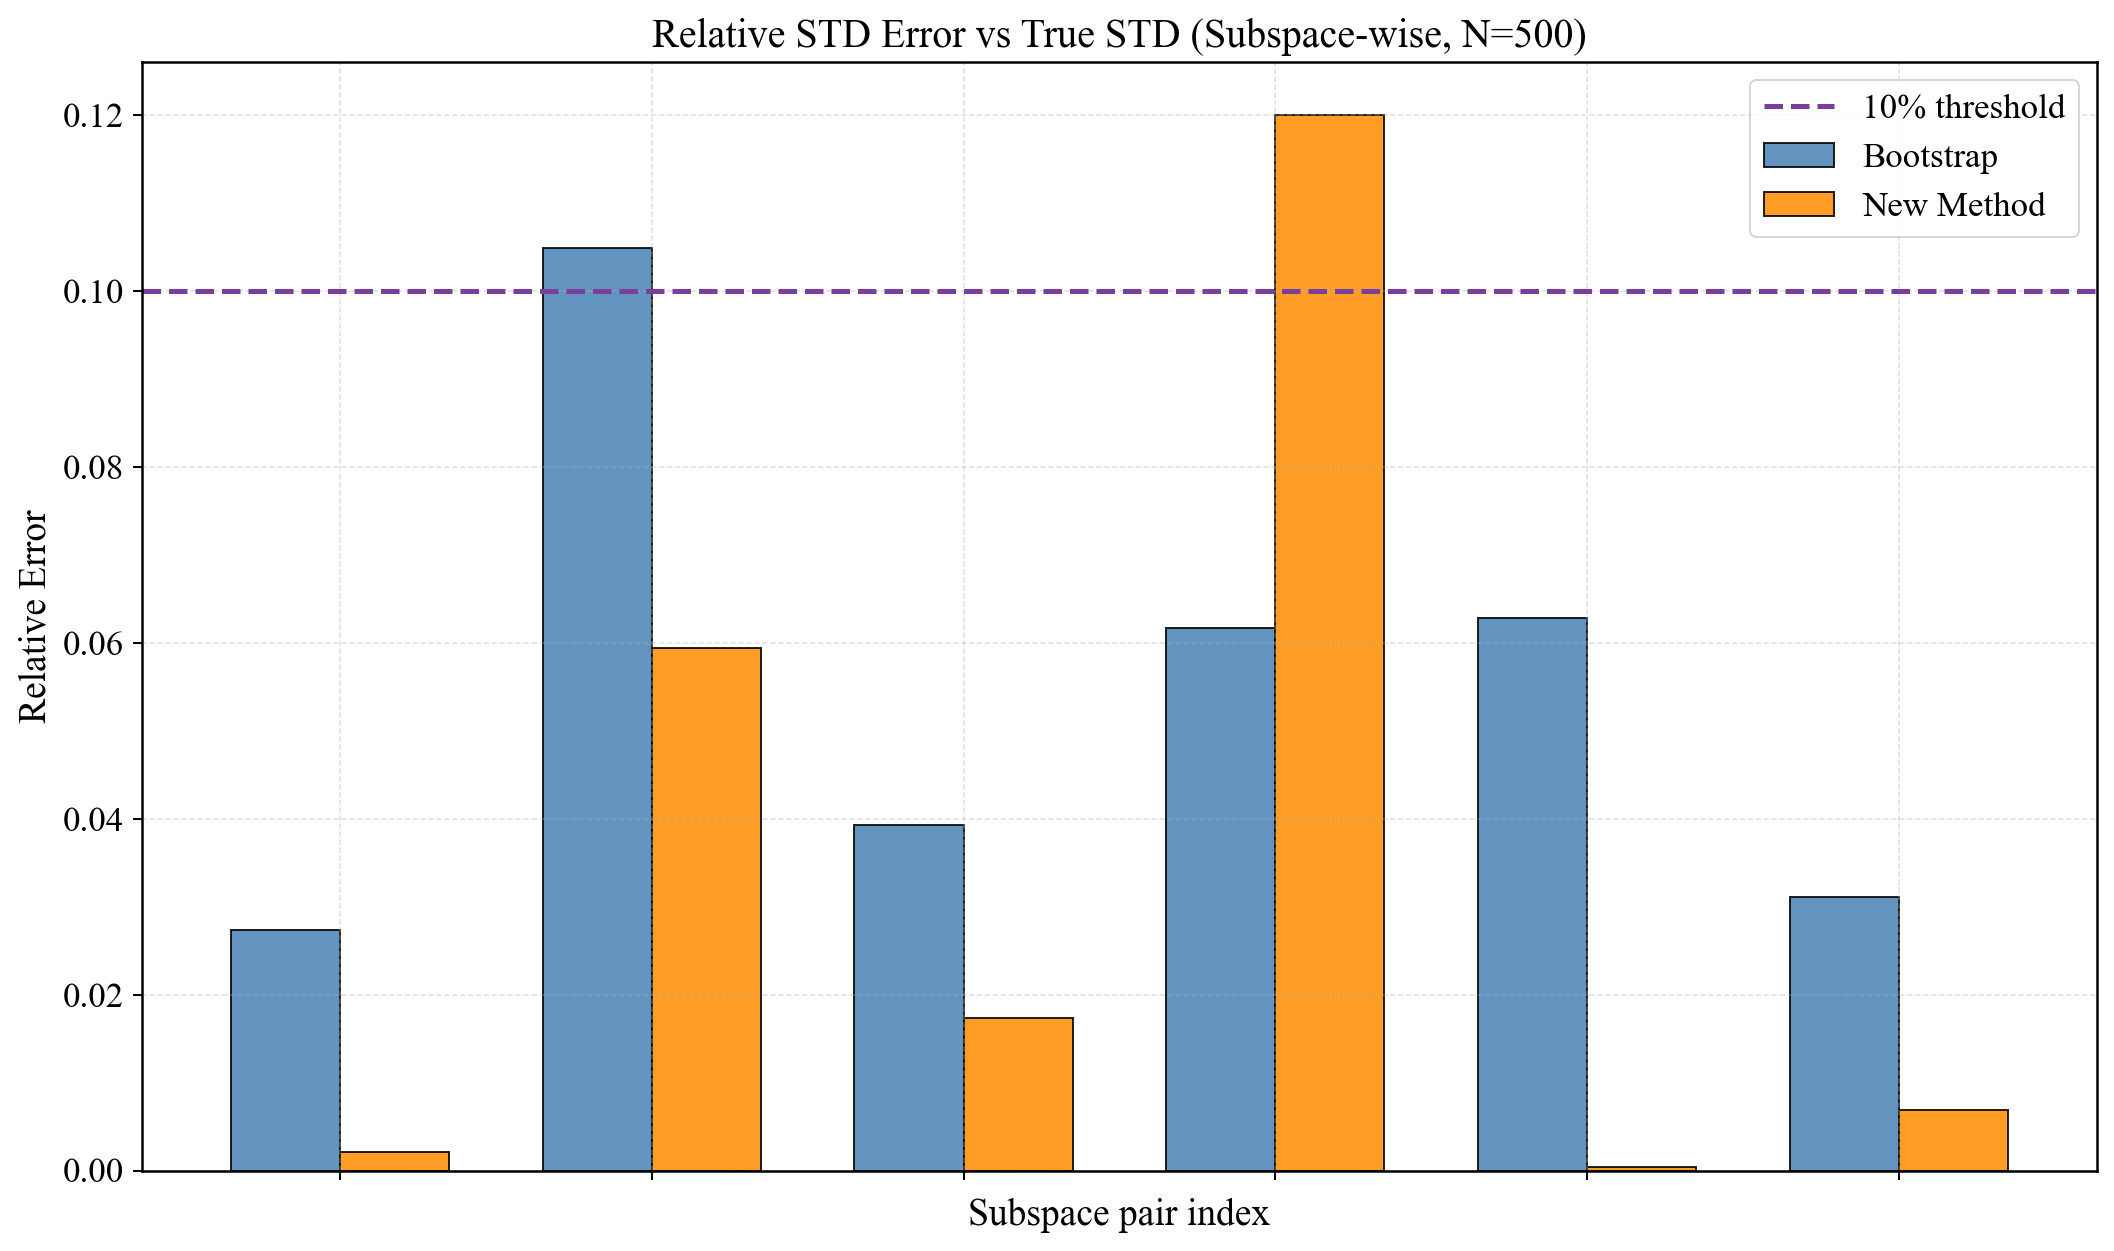

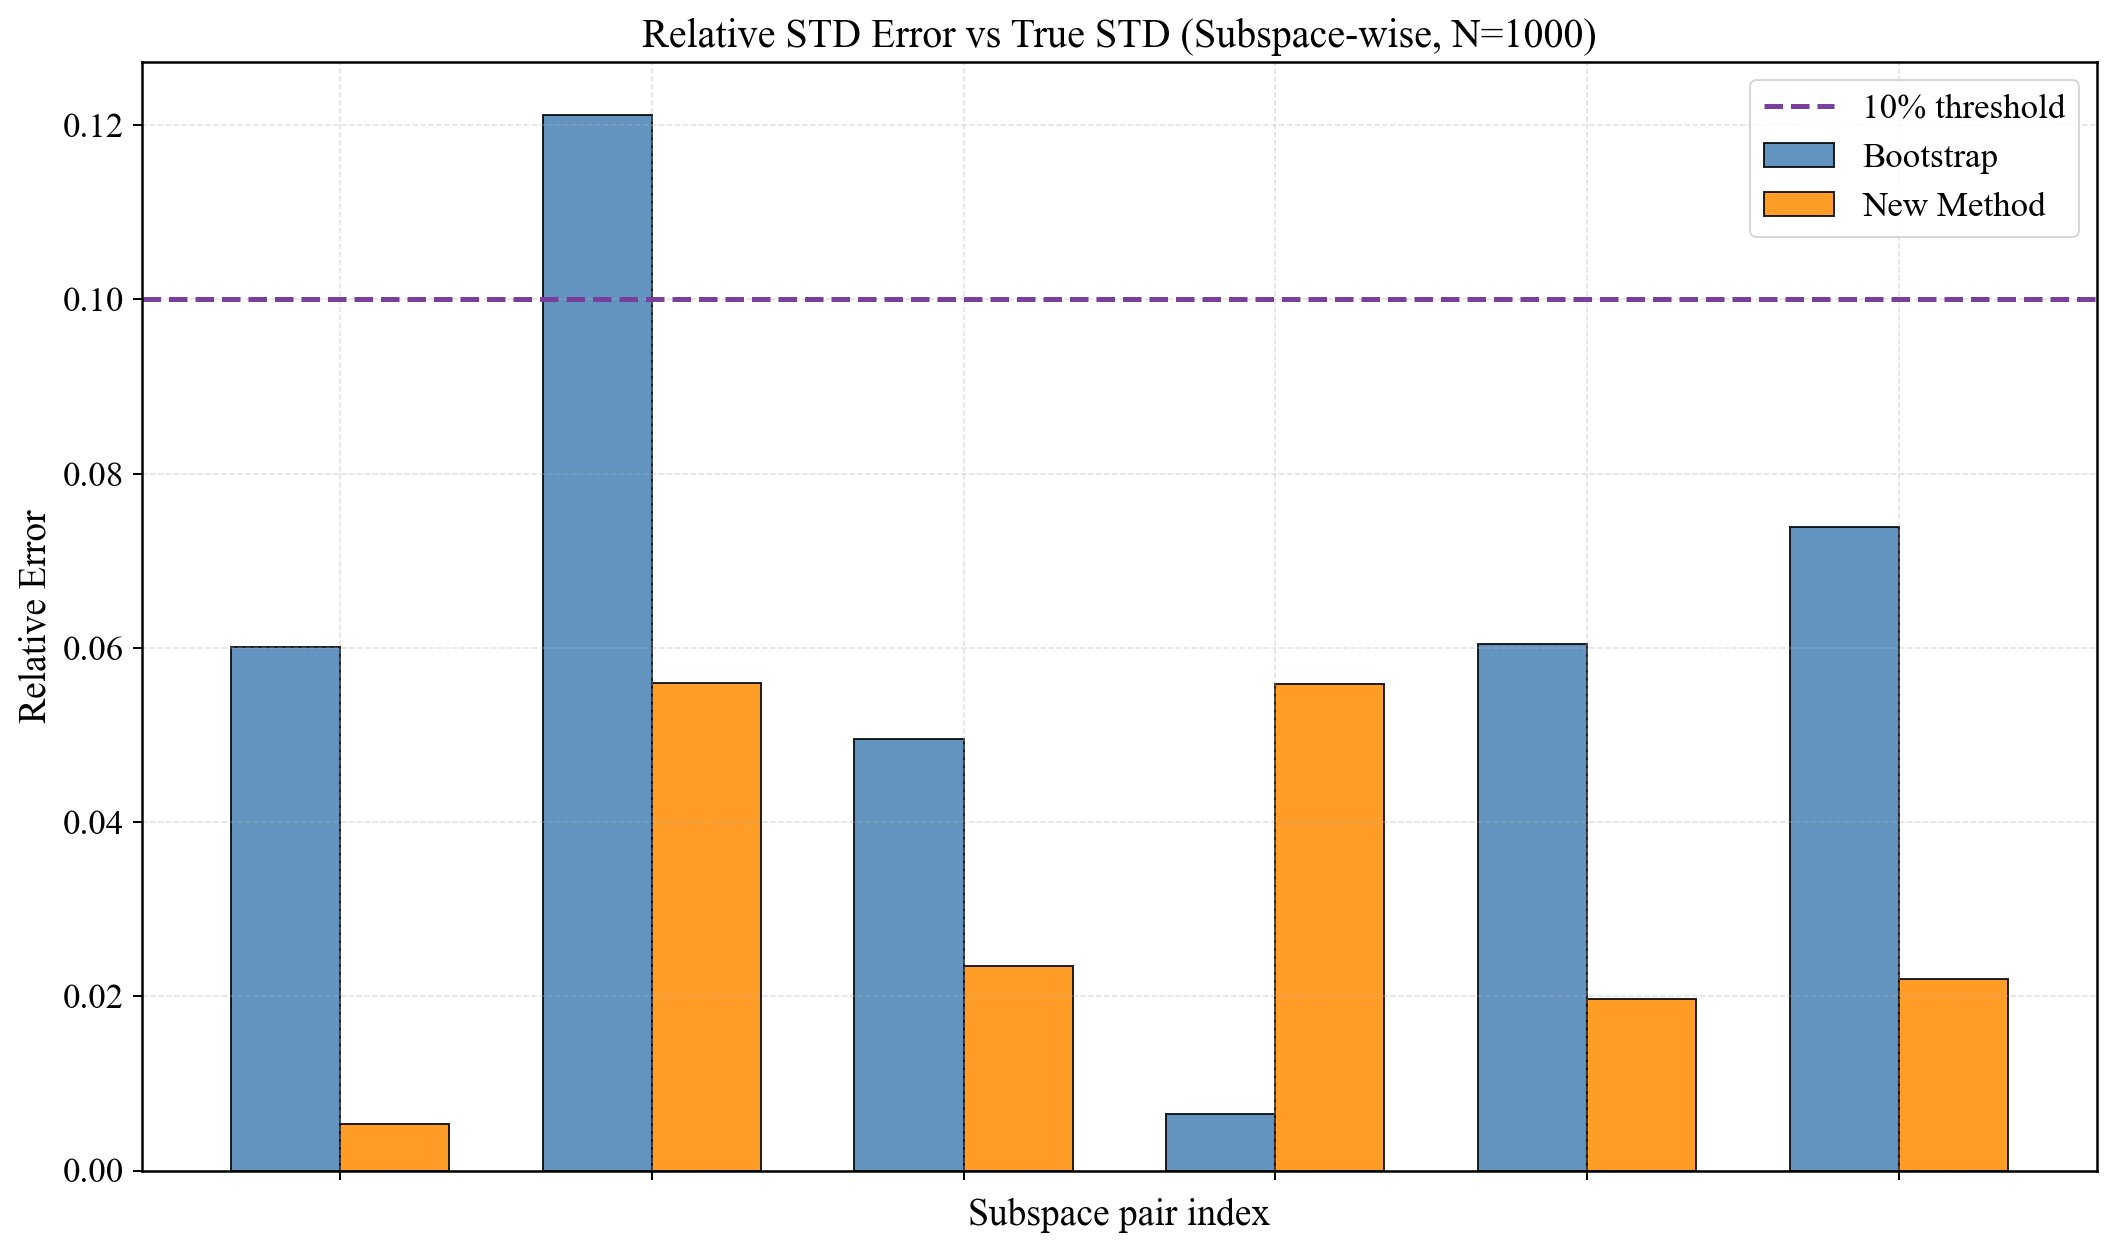

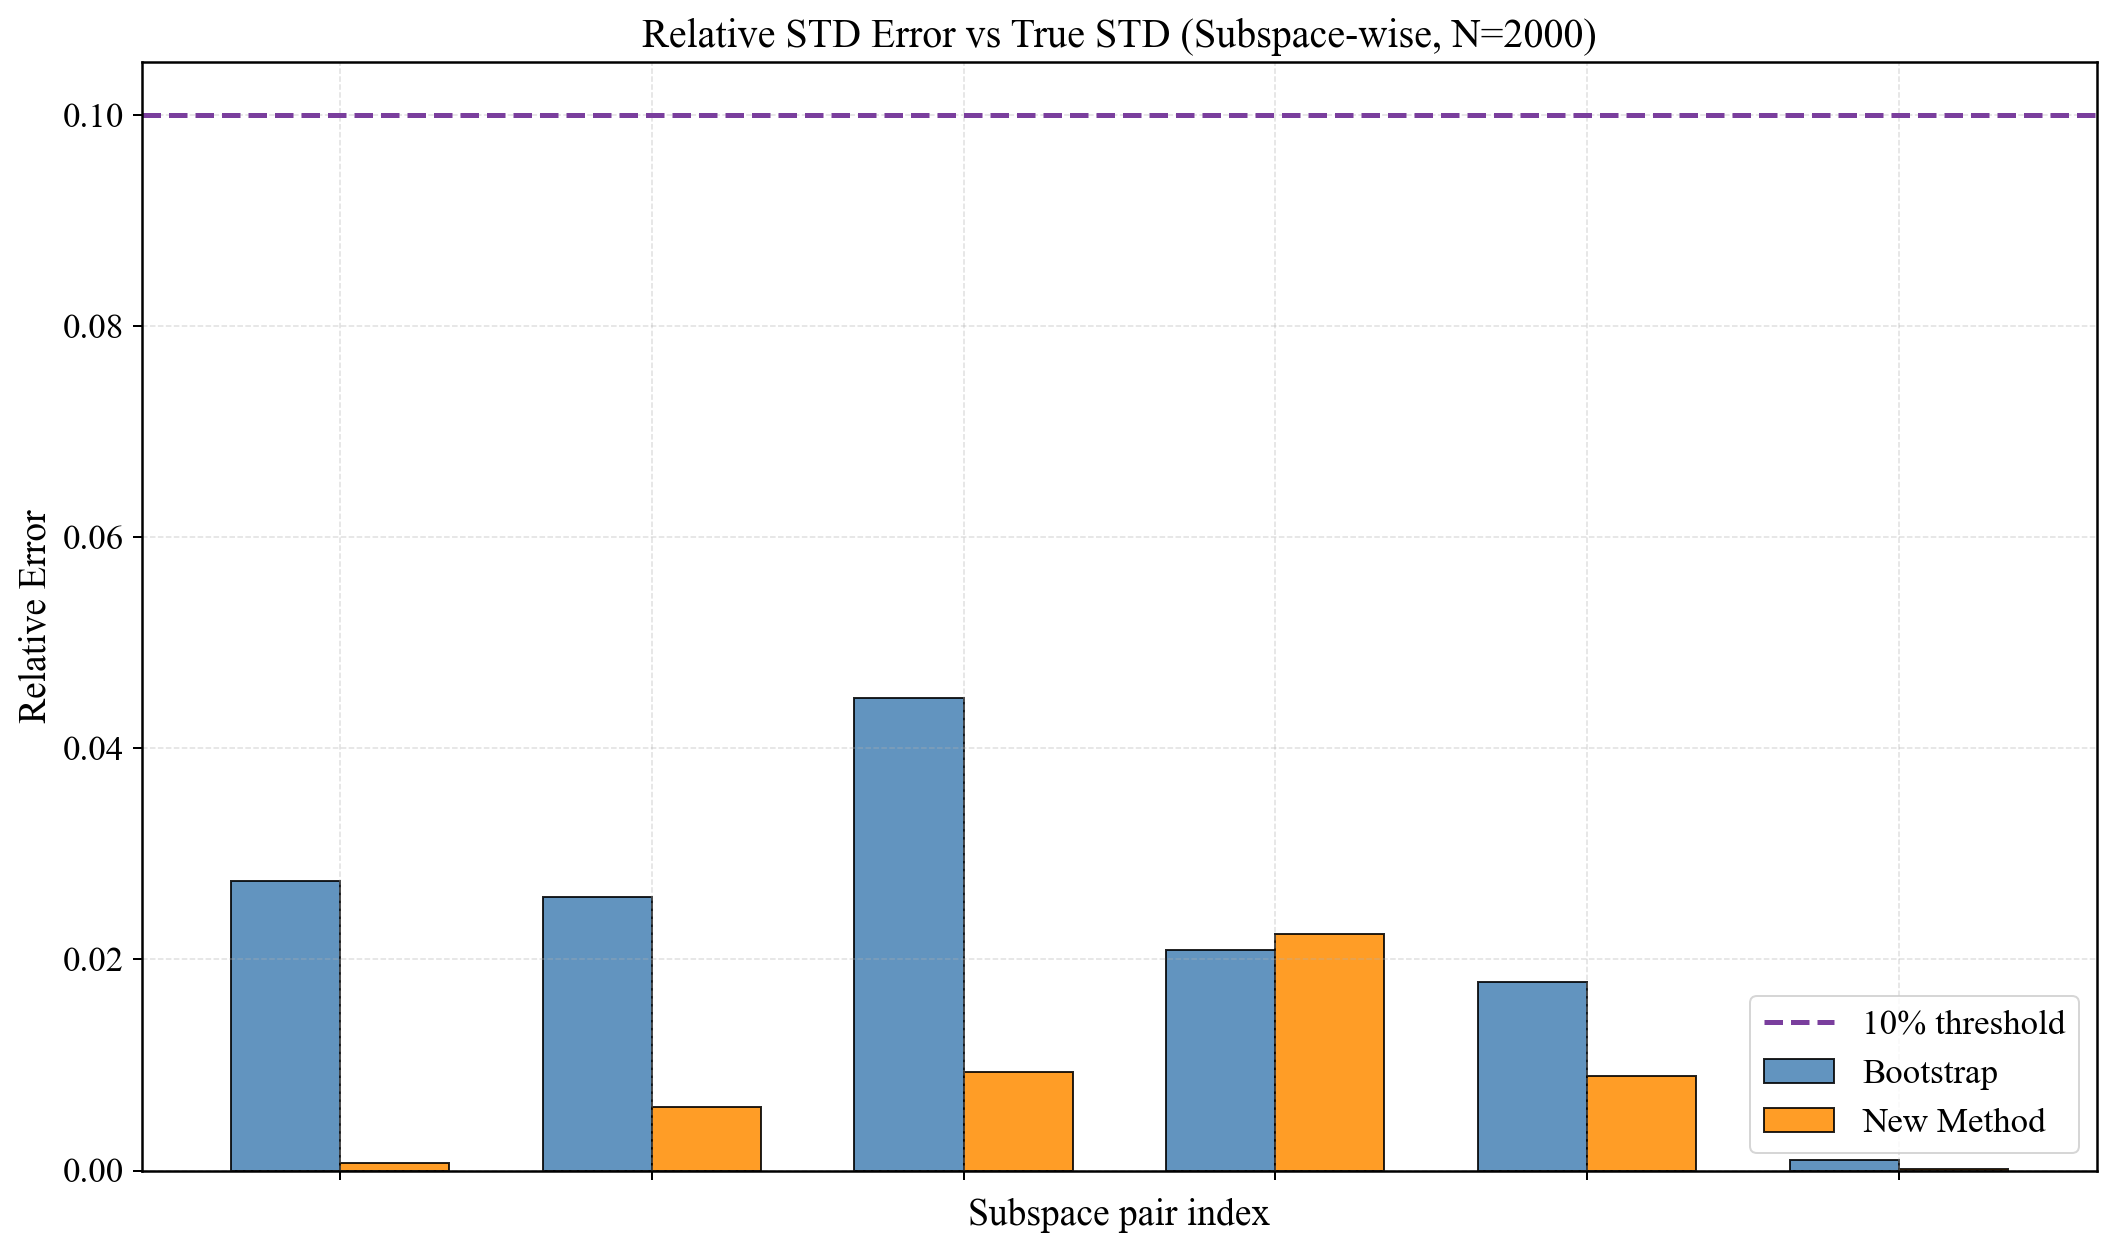

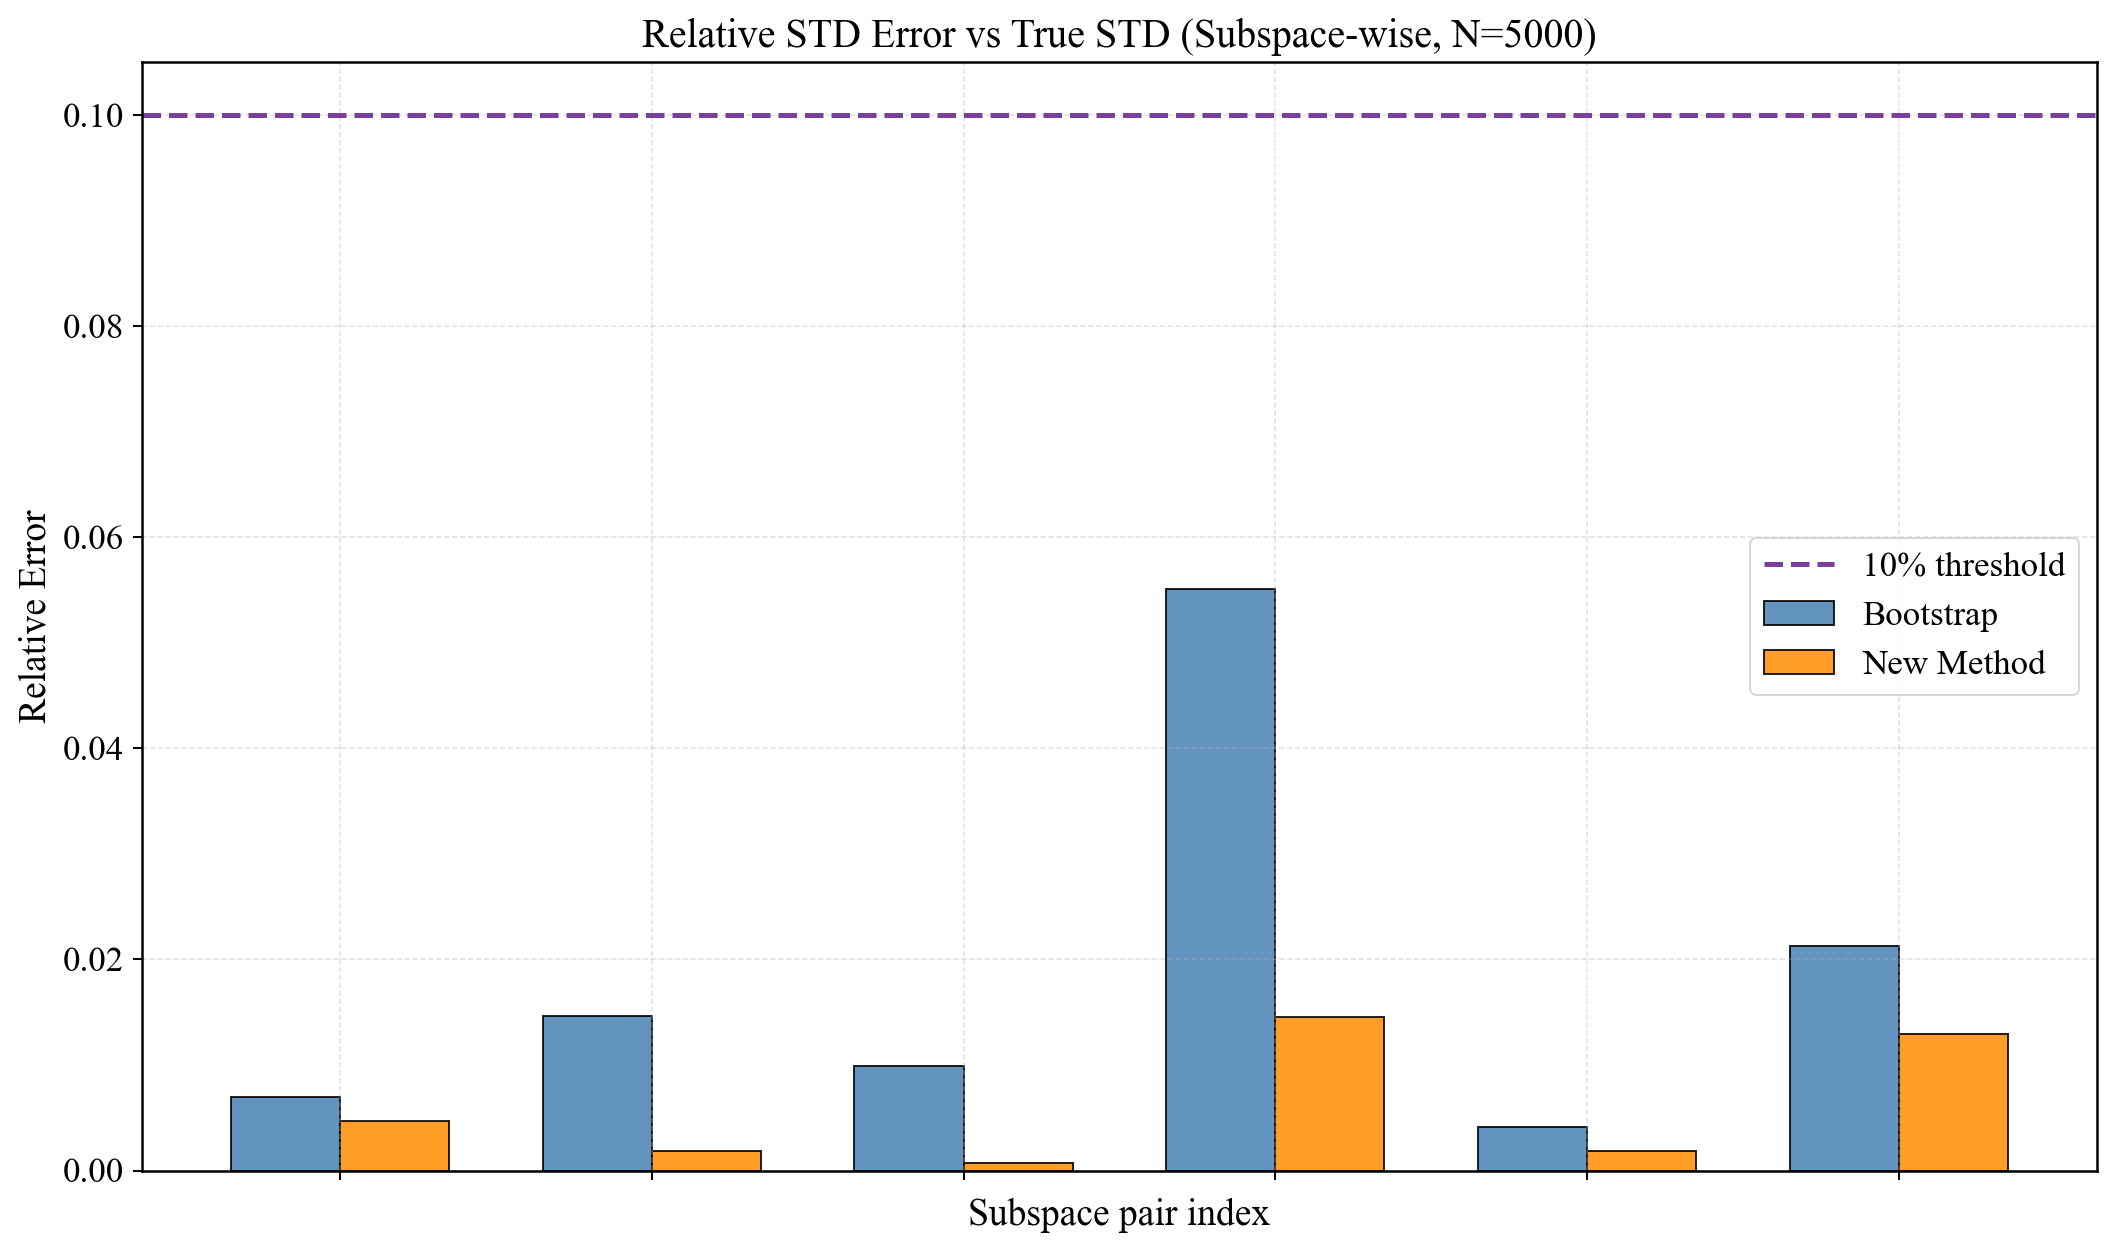

In [3]:
subspace_sizes = [500,1000,2000,5000] if RUN_MODE == "paper" else [120,240]
subspace_bootstrap_count = 1000 if RUN_MODE == "paper" else 40
SUBSPACE_SEGMENTS = [[0,1],[2,3],[4,5]]
np.random.seed(29)
subspace_B = np.random.randn(6,6); subspace_dt=.1
subspace_Sigma = solve_discrete_lyapunov(np.eye(6)+subspace_dt*FIXED_A,
                                         subspace_dt*subspace_B@subspace_B.T)
subspace_results=[]
for N in subspace_sizes:
    panel=generate_panel_data(N,FIXED_A,subspace_B,np.zeros(6),subspace_Sigma,subspace_dt,99999)
    estimate=estimate_information_flow(panel,SUBSPACE_SEGMENTS,dt=subspace_dt,data_mode="panel",ridge_lambda=0.0)
    bootstrap=bootstrap_estimate(panel,dt=subspace_dt,segments=SUBSPACE_SEGMENTS,
                                 bootstrap_num=subspace_bootstrap_count,rng=np.random)
    truth=real_information_flow_linear_case(FIXED_A,subspace_B,deg_freedom=N-6,
                                             segments=SUBSPACE_SEGMENTS,discrete_lyapunov=True,dt=subspace_dt)
    mask=off_diagonal(3); true_std=truth["information_flow_std"][mask]
    subspace_results.append({"N":N,"true_std":true_std,
        "bootstrap_error":np.abs(bootstrap["bootstrap_information_flow_std"][mask]-true_std)/true_std,
        "new_error":np.abs(estimate["information_flow_std"][mask]-true_std)/true_std})
save_json(OUTPUT_DIR/"subspace_bootstrap.json",{"results":subspace_results,"metadata":PROVENANCE})

for row in subspace_results:
    x=np.arange(len(row["new_error"])); width=.35
    fig,axis=plt.subplots(figsize=(12,7.2),dpi=180)
    axis.bar(x-width/2,row["bootstrap_error"],width,label="Bootstrap",color=C_BOOT,alpha=.85,edgecolor="black")
    axis.bar(x+width/2,row["new_error"],width,label="New Method",color=C_NEW,alpha=.85,edgecolor="black")
    axis.axhline(.1,color=C_THR,ls="--",label="10% threshold")
    axis.set(title=f"Relative STD Error vs True STD (Subspace-wise, N={row['N']})",
             xlabel="Subspace pair index",ylabel="Relative Error")
    axis.set_xticks(x,[]); axis.legend(); frame_axes([axis]); fig.tight_layout()
    save_figure(fig,f"std_comparison_s{row['N']}.png"); plt.show()


## Subspace dimension and sample-size scalability

This cell is the complete program behind Supplementary Figure S3. For each total
dimension, the coordinates are split into the three explicit half-open blocks
`[0, d//3)`, `[d//3, 2(d//3))`, and `[2(d//3), d)`. It constructs `A`, `B`, and
the stationary covariance, generates independent two-time-point panels, calls
the maintained LKIF estimator, aggregates rejection rates, and plots the new
arrays. The requested and actually accepted hard-null counts are both retained
because the historical generator can fall back to its structural-null links.


accepted hard-null count distribution: {np.int64(0): np.int64(200)}


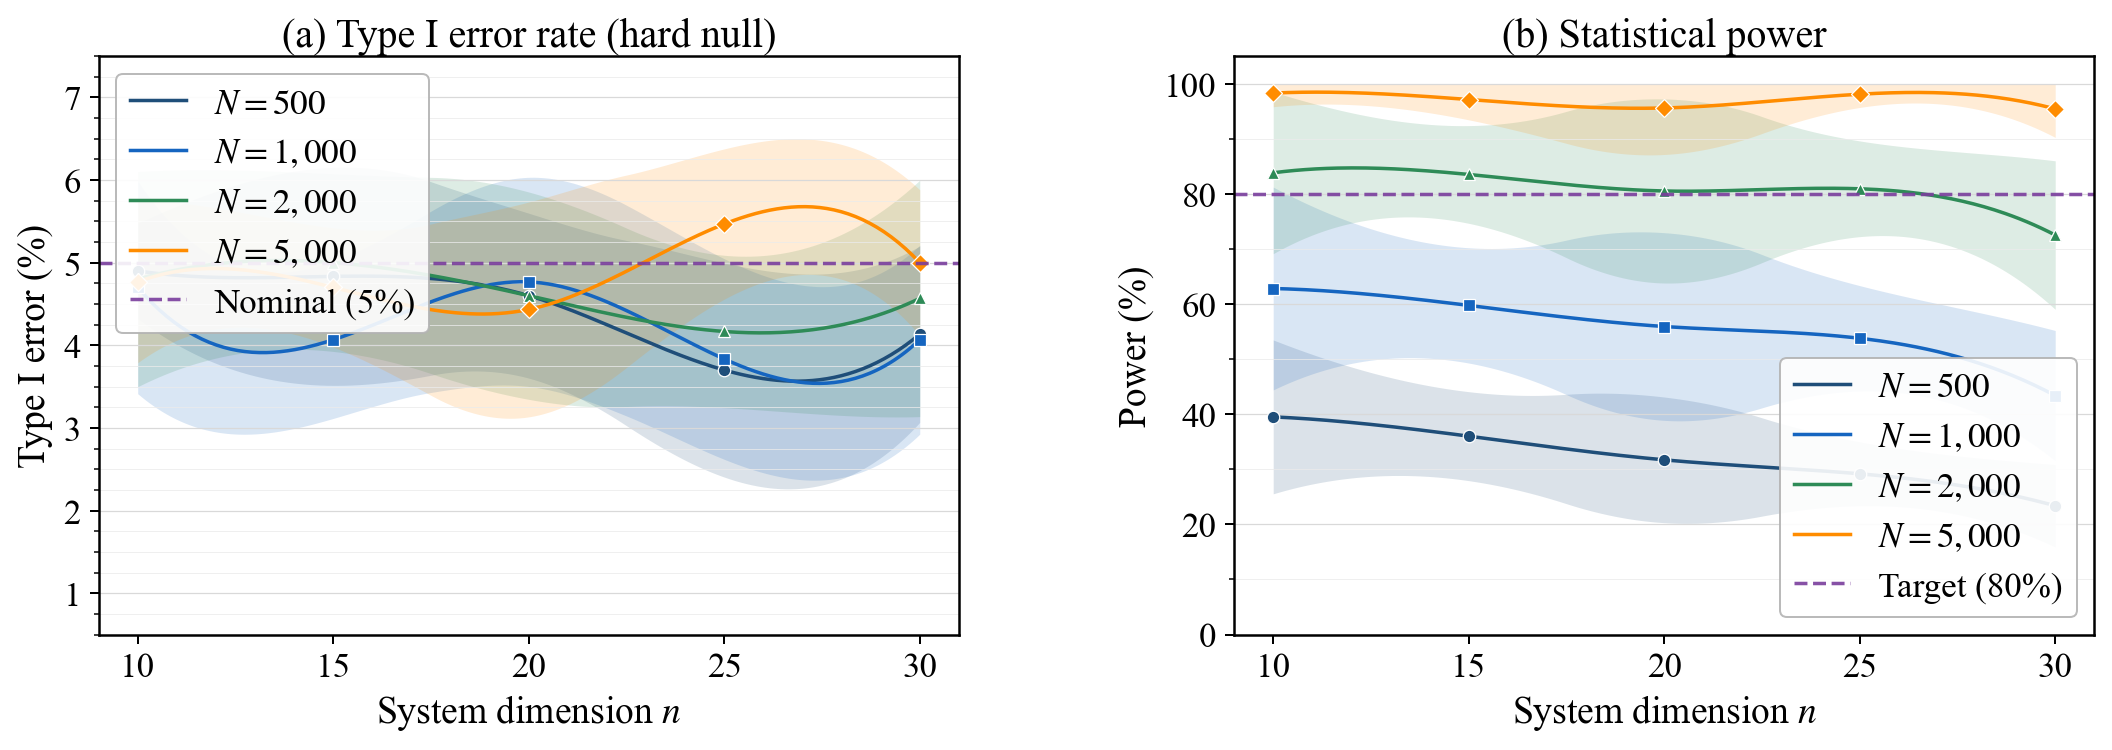

In [4]:
SCALABILITY_CFG = (
    dict(dt=.1, dimensions=[10,15,20,25,30], sample_sizes=[500,1000,2000,5000],
         n_trials=10, n_mc=100, n_hard_nulls=24)
    if RUN_MODE == "paper" else
    dict(dt=.1, dimensions=[10,15,20], sample_sizes=[120,240],
         n_trials=2, n_mc=3, n_hard_nulls=2)
)
SCALABILITY_ACTIVE_LINKS = [(0,2),(1,0),(2,1)]
SCALABILITY_FALLBACK_NULL_LINKS = [(0,1),(1,2),(2,0)]
SCALABILITY_TARGET_NULL = (0,2)

def enforce_scalability_stability(A):
    maximum_real = float(np.max(np.real(np.linalg.eigvals(A))))
    return A-(maximum_real+.1)*np.eye(A.shape[0]) if maximum_real > 0 else A

def build_scalability_system(dimension, seed):
    rng = np.random.default_rng(seed)
    d0 = d1 = dimension//3; split = d0+d1
    A = -.5*np.eye(dimension)
    A[:d0,split:] = rng.uniform(.15,.35,(d0,dimension-split))
    A[d0:split,:d0] = rng.uniform(.15,.35,(d1,d0))
    A[split:,d0:split] = rng.uniform(.15,.35,(dimension-split,d1))
    A = enforce_scalability_stability(A)
    B = rng.standard_normal((dimension,dimension))
    transition = np.eye(dimension)+SCALABILITY_CFG["dt"]*A
    Sigma = solve_discrete_lyapunov(
        transition, SCALABILITY_CFG["dt"]*B@B.T
    )
    return A,B,Sigma

def make_scalability_hard_nulls(A,B,Sigma,segments,n_variants,seed):
    rng=np.random.default_rng(seed); i,j=SCALABILITY_TARGET_NULL
    si0,si1=segments[i]; sj0,sj1=segments[j]
    reference=Sigma[sj0:sj1,si0:si1]@np.linalg.inv(Sigma[si0:si1,si0:si1])
    norm_squared=float(np.sum(reference*reference)); variants=[]
    if norm_squared < 1e-12:
        return variants
    for _ in range(4*n_variants):
        candidate=A.copy()
        block=rng.uniform(-.35,.35,(si1-si0,sj1-sj0))
        block-=float(np.trace(block@reference))/norm_squared*reference.T
        if np.linalg.norm(block)<1e-8:
            continue
        candidate[si0:si1,sj0:sj1]=block
        candidate=enforce_scalability_stability(candidate)
        transition=np.eye(candidate.shape[0])+SCALABILITY_CFG["dt"]*candidate
        candidate_Sigma=solve_discrete_lyapunov(
            transition,SCALABILITY_CFG["dt"]*B@B.T
        )
        new_reference=(candidate_Sigma[sj0:sj1,si0:si1]
                       @np.linalg.inv(candidate_Sigma[si0:si1,si0:si1]))
        null_flow=np.trace(candidate[si0:si1,sj0:sj1]@new_reference)
        if abs(null_flow)<5e-4:
            variants.append((candidate,candidate_Sigma))
            if len(variants)>=n_variants:
                break
    return variants

def scalability_rejection_rates(N,B,segments,variants,base_system,n_mc,seed_base):
    index_segments=[list(range(start,stop)) for start,stop in segments]
    null_rejections=[]; active_rejections=[]
    if variants:
        systems_to_test=variants
        null_links=[SCALABILITY_TARGET_NULL]
        active_links=[link for link in SCALABILITY_ACTIVE_LINKS
                      if link != SCALABILITY_TARGET_NULL]
        seed_for=lambda variant,mc: seed_base+10_000*variant+97*mc
    else:
        systems_to_test=[base_system]
        null_links=SCALABILITY_FALLBACK_NULL_LINKS
        active_links=SCALABILITY_ACTIVE_LINKS
        seed_for=lambda variant,mc: seed_base+99*mc
    for variant,(A,Sigma) in enumerate(systems_to_test):
        for mc in range(n_mc):
            panel=generate_panel_data(
                N,A,B,np.zeros(A.shape[0]),Sigma,SCALABILITY_CFG["dt"],
                seed_for(variant,mc),
            )
            estimate=estimate_information_flow(
                panel,index_segments,dt=SCALABILITY_CFG["dt"],
                data_mode="panel",ridge_lambda=1e-6,
            )
            z=np.abs(estimate["information_flow"])/np.maximum(
                estimate["information_flow_std"],1e-12
            )
            null_rejections.extend(float(z[link]>Z95) for link in null_links)
            active_rejections.extend(float(z[link]>Z95) for link in active_links)
    return 100*np.mean(null_rejections),100*np.mean(active_rejections)

def _scalability_task(task):
    N, dimension_index, trial = task
    dimension = SCALABILITY_CFG["dimensions"][dimension_index]
    d0 = d1 = dimension//3
    segments = [(0,d0),(d0,d0+d1),(d0+d1,dimension)]
    system_seed = trial*1000+dimension
    A,B,Sigma = build_scalability_system(dimension,system_seed)
    variants = make_scalability_hard_nulls(
        A,B,Sigma,segments,SCALABILITY_CFG["n_hard_nulls"],
        trial*10_000+dimension,
    )
    type1_rate,power_rate = scalability_rejection_rates(
        N,B,segments,variants,(A,Sigma),SCALABILITY_CFG["n_mc"],
        trial*100_000+dimension,
    )
    record = {"N":N,"dimension":dimension,"trial":trial,
              "accepted":len(variants),"used_fallback":not bool(variants)}
    system_entry = None
    if N == SCALABILITY_CFG["sample_sizes"][0]:
        system_entry = {"dimension":dimension,"trial":trial,
                        "seed":system_seed,"segments":segments,"A":A,"B":B,
                        "f":np.zeros(dimension),"Sigma":Sigma}
    return N, dimension_index, trial, type1_rate, power_rate, record, system_entry

_scalability_tasks = [(N, dimension_index, trial)
                      for N in SCALABILITY_CFG["sample_sizes"]
                      for dimension_index in range(len(SCALABILITY_CFG["dimensions"]))
                      for trial in range(SCALABILITY_CFG["n_trials"])]
_scalability_results = parallel_map(_scalability_task, _scalability_tasks)

scalability_type1={N:[[] for _ in SCALABILITY_CFG["dimensions"]]
                   for N in SCALABILITY_CFG["sample_sizes"]}
scalability_power={N:[[] for _ in SCALABILITY_CFG["dimensions"]]
                   for N in SCALABILITY_CFG["sample_sizes"]}
scalability_systems=[]; hard_null_counts=[]
for N, dimension_index, trial, type1_rate, power_rate, record, system_entry in _scalability_results:
    scalability_type1[N][dimension_index].append(type1_rate)
    scalability_power[N][dimension_index].append(power_rate)
    hard_null_counts.append(record)
    if system_entry is not None:
        scalability_systems.append(system_entry)

scalability_result={
    "config":{**SCALABILITY_CFG,"target_null_link":SCALABILITY_TARGET_NULL,
              "hard_null_active_links":[link for link in SCALABILITY_ACTIVE_LINKS
                                        if link != SCALABILITY_TARGET_NULL],
              "fallback_null_links":SCALABILITY_FALLBACK_NULL_LINKS,
              "fallback_active_links":SCALABILITY_ACTIVE_LINKS},
    "type1":scalability_type1,"power":scalability_power,
    "hard_null_counts":hard_null_counts,"systems":scalability_systems,
    "metadata":PROVENANCE,
}
save_json(OUTPUT_DIR/"subspace_scalability.json",scalability_result)
print("accepted hard-null count distribution:",
      dict(zip(*np.unique([row["accepted"] for row in hard_null_counts],return_counts=True))))

dimensions=np.asarray(SCALABILITY_CFG["dimensions"],float)
palette={500:"#1F4E79",1000:"#1565C0",2000:C_RUD,5000:C_NEW}
markers={500:"o",1000:"s",2000:"^",5000:"D"}
fallback_colors=["#1F4E79","#1565C0",C_RUD,C_NEW]
with plt.rc_context({"legend.framealpha":.9,"legend.edgecolor":".7",
                     "lines.linewidth":1.4,"lines.markersize":5}):
    fig,axes=plt.subplots(1,2,figsize=(12,4),dpi=180)
    fig.tight_layout(); fig.subplots_adjust(wspace=.32)
    dense=np.linspace(dimensions.min(),dimensions.max(),220)
    for sample_index,N in enumerate(SCALABILITY_CFG["sample_sizes"]):
        color=palette.get(N,fallback_colors[sample_index%len(fallback_colors)])
        marker=markers.get(N,("o","s","^","D")[sample_index%4])
        for axis,values in zip(axes,(scalability_type1[N],scalability_power[N])):
            array=np.asarray(values,float); center=array.mean(axis=1); spread=array.std(axis=1)
            if len(dimensions)>=4:
                smooth=make_interp_spline(dimensions,center,k=3)(dense)
                smooth_spread=np.clip(make_interp_spline(dimensions,spread,k=2)(dense),0,None)
                axis.plot(dense,smooth,label=fr"$N={N:,}$",color=color)
                axis.fill_between(dense,np.clip(smooth-smooth_spread,0,None),
                                  np.clip(smooth+smooth_spread,None,100),
                                  color=color,alpha=.16,linewidth=0)
            else:
                axis.plot(dimensions,center,label=fr"$N={N:,}$",color=color)
                axis.fill_between(dimensions,np.clip(center-spread,0,None),
                                  np.clip(center+spread,None,100),
                                  color=color,alpha=.16,linewidth=0)
            axis.plot(dimensions,center,linestyle="none",color=color,marker=marker,
                      markeredgewidth=.5,markeredgecolor="white",clip_on=False)
    axes[0].axhline(5,color=C_THR,lw=1.4,ls="--",alpha=.9,label="Nominal (5%)")
    axes[0].set_title("(a) Type I error rate (hard null)",pad=4)
    axes[0].set(xlabel=r"System dimension $n$",ylabel="Type I error (%)")
    axes[0].set_ylim((.5,7.5) if RUN_MODE=="paper" else
                     (0,max(7.5,1.15*max(np.max(scalability_type1[N])
                                        for N in SCALABILITY_CFG["sample_sizes"]))))
    axes[0].set_xticks(dimensions); axes[0].yaxis.set_minor_locator(mticker.AutoMinorLocator(4))
    axes[0].legend(loc="upper left",handlelength=1.6)
    axes[1].axhline(80,color=C_THR,lw=1.4,ls="--",alpha=.9,label="Target (80%)")
    axes[1].set_title("(b) Statistical power",pad=4)
    axes[1].set(xlabel=r"System dimension $n$",ylabel="Power (%)",ylim=(0,105))
    axes[1].set_xticks(dimensions); axes[1].yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
    axes[1].legend(loc="lower right",handlelength=1.6)
    for axis in axes:
        axis.grid(axis="y",which="major",lw=.5,color=".85")
        axis.grid(axis="y",which="minor",lw=.3,color=".92")
    save_figure(fig,"subspace_varying_dim.png",pad_inches=.05)
    plt.show()


## Stochastic Lorenz nonlinear misspecification check

Stochastic Lorenz-63 is integrated with an RK4 drift step plus additive Gaussian noise (`sigma_eps=1.0`, `dt=0.01`, seed fixed). The tested null is the structurally absent `z -> x` edge of the drift. Only the trajectory prefix required by the 200 windows is retained.

Two standard-error estimators are compared on every window: the proposed i.i.d. panel formula (`data_mode="panel"`) and the rudimentary original formula. Empirical power is recorded on the structurally present `x -> y` edge of the same windows.

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


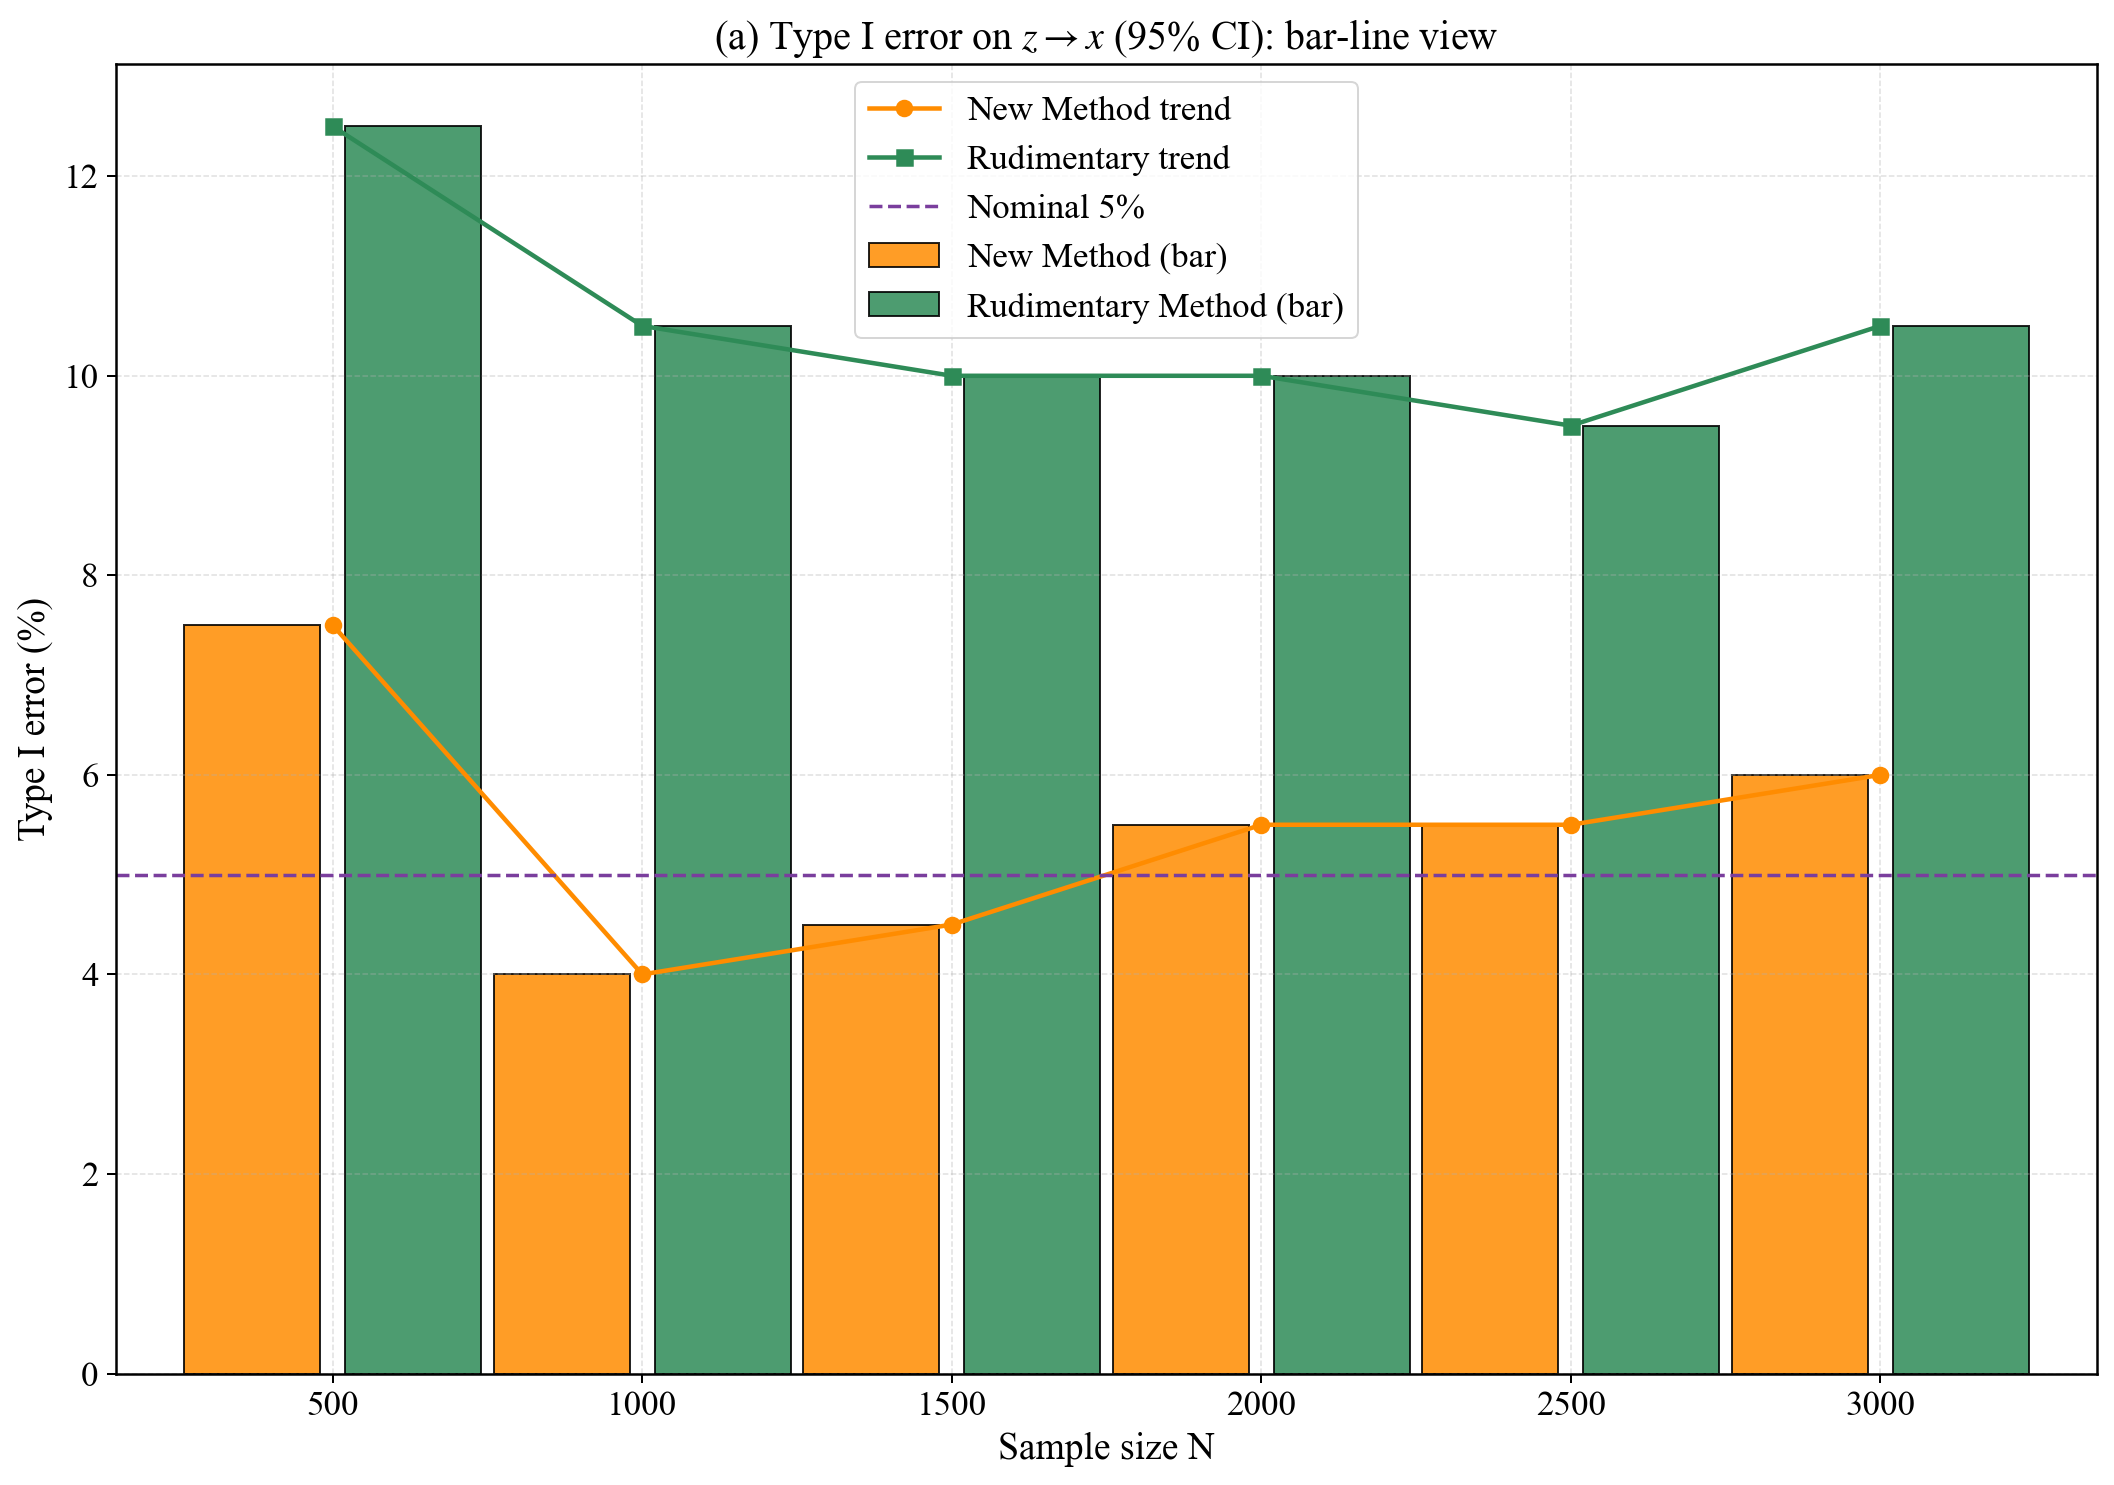

In [2]:
lorenz_dt=.01
lorenz_sizes=[500,1000,1500,2000,2500,3000] if RUN_MODE=="paper" else [120,240]
lorenz_trials=200 if RUN_MODE=="paper" else 4
lorenz_stride=2000 if RUN_MODE=="paper" else 300
lorenz_burn=int(8000/lorenz_dt) if RUN_MODE=="paper" else 1000
lorenz_noise=1.0

def lorenz_step(state,h):
    def rhs(value):
        x,y,z=value
        return np.array([10*(y-x),x*(28-z)-y,x*y-(8/3)*z])
    k1=rhs(state); k2=rhs(state+.5*h*k1); k3=rhs(state+.5*h*k2); k4=rhs(state+h*k3)
    return state+(h/6.0)*(k1+2*k2+2*k3+k4)

rng=np.random.default_rng(2024)
state=np.array([1.,1.,25.])
for _ in range(lorenz_burn):
    state=lorenz_step(state,lorenz_dt)+np.sqrt(lorenz_dt)*lorenz_noise*rng.standard_normal(3)
required=lorenz_stride*(lorenz_trials-1)+max(lorenz_sizes)
trajectory=np.empty((required,3))
for index in range(required):
    state=lorenz_step(state,lorenz_dt)+np.sqrt(lorenz_dt)*lorenz_noise*rng.standard_normal(3)
    trajectory[index]=state

lorenz_results=[]
for N in lorenz_sizes:
    z_new=[]; z_old=[]; p_new=[]; p_old=[]
    for trial in range(lorenz_trials):
        window=trajectory[trial*lorenz_stride:trial*lorenz_stride+N]
        estimate=estimate_information_flow(window,[[0],[1],[2]],dt=lorenz_dt,data_mode="panel",ridge_lambda=0.0)
        value=abs(float(estimate["information_flow"][0,2]))
        z_new.append(value/max(float(estimate["information_flow_std"][0,2]),1e-12))
        z_old.append(value/max(float(estimate["information_flow_std_origin"][0,2]),1e-12))
        alt=abs(float(estimate["information_flow"][1,0]))
        p_new.append(alt/max(float(estimate["information_flow_std"][1,0]),1e-12))
        p_old.append(alt/max(float(estimate["information_flow_std_origin"][1,0]),1e-12))
    for confidence in (.90,.95,.99):
        critical=norm.ppf(1-(1-confidence)/2)
        lorenz_results.append({"N":N,"confidence_level":confidence,"nominal":1-confidence,
                               "new":float(np.mean(np.asarray(z_new)>critical)),
                               "rudimentary":float(np.mean(np.asarray(z_old)>critical)),
                               "new_power":float(np.mean(np.asarray(p_new)>critical)),
                               "rudimentary_power":float(np.mean(np.asarray(p_old)>critical)),
                               "n_trials":lorenz_trials})
save_json(OUTPUT_DIR/"lorenz_type1.json",{"results":lorenz_results,"metadata":PROVENANCE})

reported=sorted((row for row in lorenz_results if row["confidence_level"]==.95),key=lambda row:row["N"])
x=np.asarray([row["N"] for row in reported],float)
new=np.asarray([100*row["new"] for row in reported]); old=np.asarray([100*row["rudimentary"] for row in reported])
fig,axis=plt.subplots(figsize=(12,8.5),dpi=180)
offset=130 if len(x)>2 else max(4,(x.max()-x.min())*.04); width=220 if len(x)>2 else 2*offset*.8
axis.bar(x-offset,new,width,color=C_NEW,alpha=.85,label="New Method (bar)",edgecolor="black")
axis.bar(x+offset,old,width,color=C_RUD,alpha=.85,label="Rudimentary Method (bar)",edgecolor="black")
axis.plot(x,new,color=C_NEW,marker="o",lw=1.8,label="New Method trend")
axis.plot(x,old,color=C_RUD,marker="s",lw=1.8,label="Rudimentary trend")
axis.axhline(5,color=C_THR,ls="--",lw=1.4,label="Nominal 5%")
axis.set(title=r"(a) Type I error on $z\to x$ (95% CI): bar-line view",xlabel="Sample size N",ylabel="Type I error (%)")
axis.set_xticks(x,[str(int(value)) for value in x]); axis.set_xlim(min(x)-350,max(x)+350)
axis.legend(); frame_axes([axis]); fig.tight_layout()
save_figure(fig,"lorenz_type1_power.png"); plt.show()


## Real-world application: squall-line multiscale information flow

The first figure replots the dynamic-PCA information-flow time series
(`data/squall_line_info_flow_dynamic_pca_results.csv`, 300 s steps) between 21.4 h and
28.9 h of the simulation, with pointwise 90% HAC intervals and the shallow / mature / decay
life-cycle markers. The second figure summarizes the organization- and decay-stage
causal networks among the convective ($\alpha_C$), mesoscale ($\alpha_M$), and
large-scale ($\alpha_L$) components. Both figures use the journal style set up in
the imports cell: Times New Roman, uniform 12-14 pt text, 600-DPI tightly cropped
PNG plus font-embedded PDF.

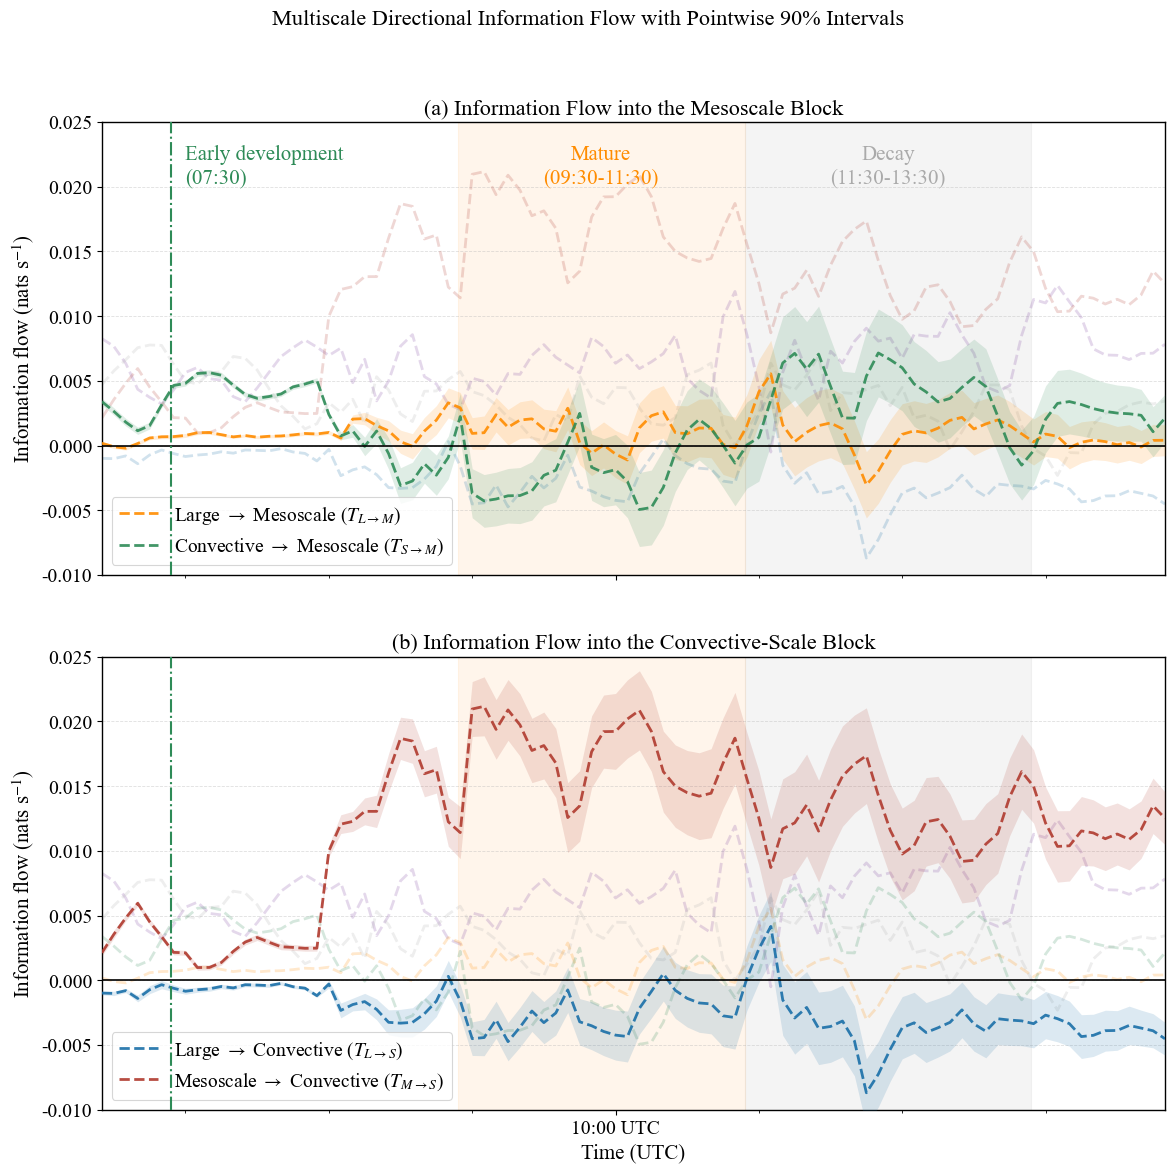

In [3]:
SQUALL_CSV = PROJECT_ROOT / "data" / "squall_line_info_flow_dynamic_pca_results.csv"
squall = np.genfromtxt(SQUALL_CSV, delimiter=",", names=True, dtype=float)

DT_SECONDS = 300.0
PLOT_START_HOURS, PLOT_END_HOURS = 21.4, 28.9
TIME_SHALLOW = 21.9        # 07:30 UTC
TIME_MATURE_START = 23.9   # 09:30 UTC
TIME_MATURE_END = 25.9     # 11:30 UTC
TIME_DECAY_END = 27.9      # 13:30 UTC

plot_time = squall["Time_Step"] * DT_SECONDS / 3600.0
window = (plot_time >= PLOT_START_HOURS) & (plot_time <= PLOT_END_HOURS)
x_data = plot_time[window]

C_NOM, C_BLUE, C_RED = "#AAAAAA", "#1A6FA8", "#B03A2E"

def sim_hour_to_utc(x, pos):
    return f"{int((x - 14.4) % 24):02d}:00 UTC"

squall_lines = {
    "T_M2L": {"label": r"Mesoscale $\to$ Large ($T_{M \to L}$)", "color": C_THR, "group": -1},
    "T_S2L": {"label": r"Convective $\to$ Large ($T_{C \to L}$)", "color": C_NOM, "group": -1},
    "T_L2M": {"label": r"Large $\to$ Mesoscale ($T_{L \to M}$)", "color": C_NEW, "group": 0},
    "T_S2M": {"label": r"Convective $\to$ Mesoscale ($T_{C \to M}$)", "color": C_RUD, "group": 0},
    "T_L2S": {"label": r"Large $\to$ Convective ($T_{L \to C}$)", "color": C_BLUE, "group": 1},
    "T_M2S": {"label": r"Mesoscale $\to$ Convective ($T_{M \to C}$)", "color": C_RED, "group": 1},
}
squall_titles = [
    "(a) Information Flow into the Mesoscale Block",
    "(b) Information Flow into the Convective-Scale Block",
]

fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=True, sharey=True)
for i, axis in enumerate(axes):
    for var_name, config in squall_lines.items():
        values = squall[var_name][window]
        errors = squall[f"{var_name}_err"][window]
        if config["group"] == i:
            axis.plot(x_data, values, label=config["label"], color=config["color"],
                      lw=2.0, ls="--", alpha=0.9, zorder=4)
            axis.fill_between(x_data, values - errors, values + errors,
                              color=config["color"], alpha=0.15, lw=0, zorder=3)
        else:
            axis.plot(x_data, values, color=config["color"], lw=2.0, ls="--",
                      alpha=0.2, zorder=2, label="_nolegend_")
    axis.set_title(squall_titles[i])
    axis.set_ylabel(r"Information flow (nats s$^{-1}$)")
    axis.legend(loc="lower left", frameon=True)
    axis.axhline(0, color="black", lw=1.2, zorder=5)
    axis.set_xlim(x_data.min(), x_data.max())
    axis.set_ylim(-0.01, 0.025)
    axis.xaxis.set_major_locator(mticker.MultipleLocator(5))
    axis.xaxis.set_minor_locator(mticker.MultipleLocator(1))
    axis.xaxis.set_major_formatter(mticker.FuncFormatter(sim_hour_to_utc))
    axis.grid(True, axis="y", ls="--", alpha=0.4)
    axis.grid(False, axis="x")
    for spine in axis.spines.values():
        spine.set_visible(True); spine.set_color("black")
    axis.axvspan(TIME_MATURE_START, TIME_MATURE_END, color=C_NEW, alpha=0.08, zorder=1)
    axis.axvspan(TIME_MATURE_END, TIME_DECAY_END, color=C_NOM, alpha=0.12, zorder=1)
    axis.axvline(x=TIME_SHALLOW, color=C_RUD, ls="-.", lw=1.5, zorder=6)

y_min, y_max = axes[0].get_ylim()
text_y = y_max - (y_max - y_min) * 0.05
axes[0].text(TIME_SHALLOW + 0.1, text_y, "Early development\n(07:30)", color=C_RUD, ha="left", va="top")
axes[0].text((TIME_MATURE_START + TIME_MATURE_END) / 2, text_y, "Mature\n(09:30-11:30)",
             color=C_NEW, ha="center", va="top")
axes[0].text((TIME_MATURE_END + TIME_DECAY_END) / 2, text_y, "Decay\n(11:30-13:30)",
             color=C_NOM, ha="center", va="top")
axes[-1].set_xlabel("Time (UTC)")
fig.suptitle("Multiscale Directional Information Flow with 90% HAC Intervals", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.subplots_adjust(hspace=0.18)
save_figure(fig, "squall_line_multiscale_2panels_with_ci.png")
plt.show()


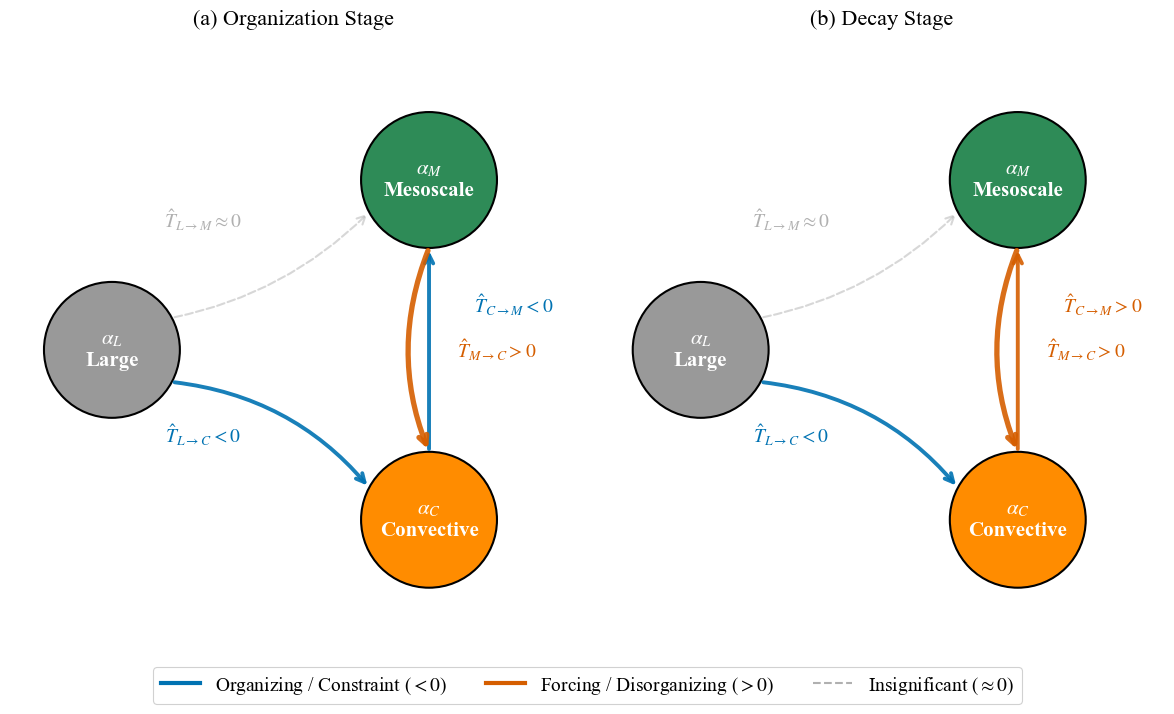

In [18]:
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

C_SMALL, C_MESO, C_LARGE = "#FF8C00", "#2E8B57", "#999999"
C_POSITIVE, C_NEGATIVE, C_INSIGNIFICANT = "#D55E00", "#0072B2", "#B0B0B0"

node_pos = {"C": (0.74, 0.15), "M": (0.74, 0.75), "L": (0.18, 0.45)}

def draw_node(axis, pos, label, color, radius=0.12):
    axis.add_patch(Circle(pos, radius, facecolor=color, edgecolor="black", lw=1.5, zorder=3))
    axis.text(*pos, label, ha="center", va="center", fontsize=15,
              fontweight="bold", color="white", zorder=4)

def draw_arrow(axis, start, end, color, linewidth=2.5, label=None,
               label_offset=(0, 0.05), significance="significant", curvature=0):
    dx, dy = end[0] - start[0], end[1] - start[1]
    ratio = 0.12 / np.hypot(dx, dy)
    start_adj = (start[0] + dx * ratio, start[1] + dy * ratio)
    end_adj = (end[0] - dx * ratio, end[1] - dy * ratio)
    linestyle = "--" if significance == "insignificant" else "-"
    alpha = 0.5 if significance == "insignificant" else 0.9
    axis.annotate("", xy=end_adj, xytext=start_adj,
                  arrowprops=dict(arrowstyle="->", color=color, lw=linewidth,
                                  ls=linestyle, alpha=alpha,
                                  connectionstyle=f"arc3,rad={curvature}"))
    if label:
        axis.text((start[0] + end[0]) / 2 + label_offset[0],
                  (start[1] + end[1]) / 2 + label_offset[1],
                  label, ha="center", va="center", fontsize=14, fontweight="bold",
                  color=color,
                  bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                            edgecolor="none", alpha=0.8))

def draw_stage_panel(axis, title, arrows):
    axis.set_xlim(0, 1); axis.set_ylim(-0.05, 1)
    axis.set_aspect("equal"); axis.axis("off")
    axis.set_title(title, fontsize=16, pad=10)
    draw_node(axis, node_pos["C"], r"$\alpha_C$" + "\nConvective", C_SMALL)
    draw_node(axis, node_pos["M"], r"$\alpha_M$" + "\nMesoscale", C_MESO)
    draw_node(axis, node_pos["L"], r"$\alpha_L$" + "\nLarge-scale", C_LARGE)
    for arrow in arrows:
        draw_arrow(axis, node_pos[arrow["from"]], node_pos[arrow["to"]],
                   color=arrow.get("color", C_POSITIVE),
                   linewidth=arrow.get("width", 2.5),
                   label=arrow.get("label"),
                   label_offset=arrow.get("label_offset", (0, 0.05)),
                   significance=arrow.get("significance", "significant"),
                   curvature=arrow.get("curvature", 0))

organization_arrows = [
    {"from": "C", "to": "M", "color": C_NEGATIVE, "width": 2.8,
     "label": r"$\hat{T}_{C\to M}<0$", "label_offset": (0.15, 0.08)},
    {"from": "L", "to": "C", "color": C_NEGATIVE, "width": 2.8,
     "label": r"$\hat{T}_{L\to C}<0$", "label_offset": (-0.12, 0), "curvature": -0.2},
    {"from": "M", "to": "C", "color": C_POSITIVE, "width": 3.8,
     "label": r"$\hat{T}_{M\to C}>0$", "label_offset": (0.12, 0), "curvature": 0.2},
    {"from": "L", "to": "M", "color": C_INSIGNIFICANT, "width": 1.5,
     "label": r"$\hat{T}_{L\to M}\approx 0$", "label_offset": (-0.12, 0.08),
     "significance": "insignificant", "curvature": 0.15},
]
decay_arrows = [
    {"from": "C", "to": "M", "color": C_POSITIVE, "width": 2.8,
     "label": r"$\hat{T}_{C\to M}>0$", "label_offset": (0.15, 0.08)},
    {"from": "L", "to": "C", "color": C_NEGATIVE, "width": 2.8,
     "label": r"$\hat{T}_{L\to C}<0$", "label_offset": (-0.12, 0), "curvature": -0.2},
    {"from": "M", "to": "C", "color": C_POSITIVE, "width": 3.8,
     "label": r"$\hat{T}_{M\to C}>0$", "label_offset": (0.12, 0), "curvature": 0.2},
    {"from": "L", "to": "M", "color": C_INSIGNIFICANT, "width": 1.5,
     "label": r"$\hat{T}_{L\to M}\approx 0$", "label_offset": (-0.12, 0.08),
     "significance": "insignificant", "curvature": 0.15},
]

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
fig.patch.set_facecolor("white")
draw_stage_panel(axes[0], "(a) Mature Organization", organization_arrows)
draw_stage_panel(axes[1], "(b) Decay Interval", decay_arrows)
legend_handles = [
    Line2D([0], [0], color=C_NEGATIVE, linewidth=3, linestyle="-",
           label="Negative signed information flow ($< 0$)"),
    Line2D([0], [0], color=C_POSITIVE, linewidth=3, linestyle="-",
           label="Positive signed information flow ($> 0$)"),
    Line2D([0], [0], color=C_INSIGNIFICANT, linewidth=1.5, linestyle="--",
           label="Not significantly different from zero ($\\approx 0$)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, frameon=True,
           framealpha=0.9, edgecolor="#cccccc", bbox_to_anchor=(0.5, 0.0))
fig.tight_layout(rect=[0, 0.08, 1, 1])
save_figure(fig, "squall_line_causal_network.png")
plt.show()
